# 🌍 Air Quality Risk Prediction & Public Health Analytics
### Data Science for Social Good Munich
---
**Dataset:** 438,010 hourly readings · 10 global cities · 5 years (2019–2023)  
**Goal:** Identify high-risk pollution zones, model AQI trends, and predict future air quality  
**Pollutants tracked:** AQI · PM2.5 · PM10 · NO₂ · CO · O₃

---
## Table of Contents
1. [Environment Setup](#1)
2. [Data Generation — Large Synthetic Dataset](#2)
3. [Data Loading & First Look](#3)
4. [Data Cleaning & Validation](#4)
5. [Exploratory Data Analysis (EDA)](#5)
6. [Daily Aggregation & Feature Engineering](#6)
7. [Machine Learning — Model Training](#7)
8. [Model Evaluation & Comparison](#8)
9. [Feature Importance Analysis](#9)
10. [City-level Risk Profiling](#10)
11. [Forecasting — Next 30 Days](#11)
12. [Final Summary & Recommendations](#12)


## 1. Environment Setup <a id='1'></a>

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import pickle
from datetime import datetime

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

os.makedirs("data",    exist_ok=True)
os.makedirs("models",  exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("✅ All libraries loaded successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   xgboost {xgb.__version__}")


✅ All libraries loaded successfully
   pandas  2.3.3
   numpy   2.3.5
   xgboost 3.2.0


## 2. Data Generation — Large Synthetic Dataset <a id='2'></a>
> Simulates realistic 5-year hourly readings across 10 cities with:
> - Rush-hour spikes, seasonal patterns, weekend dips
> - City-specific pollution baselines
> - Long-term improvement trend
> - ~5 % injected missing values


In [2]:
# ── City pollution profiles ────────────────────────────────────────────────────
CITY_PROFILES = {
    "Delhi":      {"base_aqi": 180, "base_pm25": 95,  "base_pm10": 180,
                   "base_no2": 65,  "base_co": 2.40},
    "Beijing":    {"base_aqi": 160, "base_pm25": 85,  "base_pm10": 160,
                   "base_no2": 70,  "base_co": 2.10},
    "Cairo":      {"base_aqi": 145, "base_pm25": 75,  "base_pm10": 145,
                   "base_no2": 55,  "base_co": 2.00},
    "Lagos":      {"base_aqi": 130, "base_pm25": 60,  "base_pm10": 120,
                   "base_no2": 45,  "base_co": 1.80},
    "São Paulo":  {"base_aqi":  95, "base_pm25": 35,  "base_pm10":  70,
                   "base_no2": 50,  "base_co": 1.20},
    "Tokyo":      {"base_aqi":  58, "base_pm25": 16,  "base_pm10":  30,
                   "base_no2": 32,  "base_co": 0.55},
    "New York":   {"base_aqi":  55, "base_pm25": 15,  "base_pm10":  28,
                   "base_no2": 35,  "base_co": 0.70},
    "London":     {"base_aqi":  50, "base_pm25": 14,  "base_pm10":  24,
                   "base_no2": 38,  "base_co": 0.60},
    "Munich":     {"base_aqi":  45, "base_pm25": 12,  "base_pm10":  22,
                   "base_no2": 28,  "base_co": 0.50},
    "Sydney":     {"base_aqi":  40, "base_pm25": 10,  "base_pm10":  18,
                   "base_no2": 22,  "base_co": 0.40},
}

CITY_COORDS = {
    "Delhi":     (28.61,  77.21), "Beijing":   (39.90, 116.41),
    "Cairo":     (30.04,  31.24), "Lagos":     ( 6.52,   3.38),
    "São Paulo": (-23.55,-46.63), "Tokyo":     (35.68, 139.65),
    "New York":  (40.71, -74.01), "London":    (51.51,  -0.13),
    "Munich":    (48.14,  11.58), "Sydney":    (-33.87, 151.21),
}

print(f"📍 {len(CITY_PROFILES)} cities configured")
print(pd.DataFrame(CITY_PROFILES).T[["base_aqi","base_pm25","base_co"]]
        .sort_values("base_aqi", ascending=False).to_string())


📍 10 cities configured
           base_aqi  base_pm25  base_co
Delhi         180.0       95.0     2.40
Beijing       160.0       85.0     2.10
Cairo         145.0       75.0     2.00
Lagos         130.0       60.0     1.80
São Paulo      95.0       35.0     1.20
Tokyo          58.0       16.0     0.55
New York       55.0       15.0     0.70
London         50.0       14.0     0.60
Munich         45.0       12.0     0.50
Sydney         40.0       10.0     0.40


In [3]:
# ── Data generator function ────────────────────────────────────────────────────
np.random.seed(42)

START, END = "2019-01-01", "2023-12-31"
date_range = pd.date_range(START, END, freq="h")
N = len(date_range)

print(f"📅 Generating {N:,} hourly timestamps per city "
      f"({len(CITY_PROFILES)} cities = {N * len(CITY_PROFILES):,} rows total)")

def generate_city_data(city, cfg, dates):
    month       = np.array(dates.month,     dtype=float)
    hour        = np.array(dates.hour,      dtype=float)
    day_of_week = np.array(dates.dayofweek, dtype=float)
    year        = np.array(dates.year,      dtype=float)

    # Seasonal multiplier — winter peaks in Northern Hemisphere
    seasonal  = 1 + 0.35 * np.cos((month - 1) * 2 * np.pi / 12 + np.pi)

    # Rush-hour multiplier (dual Gaussian: 8 am + 6 pm)
    rush_hour = 1 + 0.25 * (
        np.exp(-0.5 * ((hour -  8) / 1.5) ** 2) +
        np.exp(-0.5 * ((hour - 18) / 1.5) ** 2)
    )

    # Weekend reduction
    weekend = np.where(day_of_week >= 5, 0.85, 1.0)

    # Gradual improvement trend (−3 % over 5 years)
    trend = 1 - 0.03 * (year - 2019) / 4

    multiplier = seasonal * rush_hour * weekend * trend
    noise = lambda s: np.random.normal(0, s, N)

    def make(base, noise_frac=0.20, lo=0, hi=None):
        arr = np.clip(base * multiplier + noise(base * noise_frac), lo, hi).astype(float)
        arr[np.random.random(N) < 0.05] = np.nan   # inject 5 % missing
        return arr

    aqi      = make(cfg["base_aqi"],  0.18, 0, 500)
    pm25     = make(cfg["base_pm25"], 0.20, 0)
    pm10     = make(cfg["base_pm10"], 0.20, 0)
    no2      = make(cfg["base_no2"],  0.15, 0)
    co       = make(cfg["base_co"],   0.15, 0)
    o3       = np.clip(30 + 20*np.sin((hour-12)*np.pi/12) + noise(8), 0, None).astype(float)
    o3[np.random.random(N) < 0.05] = np.nan
    temp     = (15 + 15*np.sin((month-4)*2*np.pi/12) + noise(3))
    humidity = (60 + 20*np.cos((month-7)*2*np.pi/12) + noise(8))

    return pd.DataFrame({
        "timestamp":   dates,  "city":        city,
        "aqi":         aqi.round(1),   "pm25":  pm25.round(2),
        "pm10":        pm10.round(2),  "no2":   no2.round(2),
        "co":          co.round(3),    "o3":    o3.round(2),
        "temperature": temp.round(1),  "humidity": humidity.round(1),
    })


📅 Generating 43,801 hourly timestamps per city (10 cities = 438,010 rows total)


In [4]:
# ── Generate & save the full dataset ──────────────────────────────────────────
print("⚙  Building dataset … (this takes ~10 seconds)")
t0 = datetime.now()

frames = [generate_city_data(city, cfg, date_range)
          for city, cfg in CITY_PROFILES.items()]
df_raw = pd.concat(frames, ignore_index=True)

elapsed = (datetime.now() - t0).seconds
print(f"✅ Generated in {elapsed}s")
print(f"   Shape       : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Memory usage: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")

df_raw.to_parquet("data/air_quality_raw.parquet", index=False)
print("💾 Saved → data/air_quality_raw.parquet")
df_raw.sample(5)


⚙  Building dataset … (this takes ~10 seconds)
✅ Generated in 0s
   Shape       : 438,010 rows × 10 columns
   Memory usage: 56.4 MB
💾 Saved → data/air_quality_raw.parquet


,timestamp,city,aqi,pm25,pm10,no2,co,o3,temperature,humidity
382695,2022-09-07 07:00:00,Munich,67.2,15.06,26.65,36.49,NaN,17.93,23.0,64.9
105573,2021-01-18 19:00:00,Cairo,101.7,39.01,103.34,30.01,1.496,51.24,-0.9,39.2
207332,2022-08-31 16:00:00,São Paulo,131.6,52.95,109.69,73.43,1.517,48.60,31.7,94.2
363179,2020-06-16 03:00:00,Munich,71.1,16.02,27.65,32.05,0.741,0.00,25.5,68.1
234328,2020-09-30 11:00:00,Tokyo,59.2,27.75,29.50,47.11,0.802,33.31,24.1,62.6


## 3. Data Loading & First Look <a id='3'></a>

In [5]:
df = pd.read_parquet("data/air_quality_raw.parquet")

print("── Shape ────────────────────────────────────────────")
print(f"   Rows: {len(df):,}   Columns: {df.shape[1]}")

print("\n── Data types ───────────────────────────────────────")
print(df.dtypes.to_string())

print("\n── Date range ───────────────────────────────────────")
print(f"   {df['timestamp'].min()}  →  {df['timestamp'].max()}")

print("\n── Cities ───────────────────────────────────────────")
print(df["city"].value_counts().to_string())

print("\n── First 3 rows ─────────────────────────────────────")
df.head(3)


── Shape ────────────────────────────────────────────
   Rows: 438,010   Columns: 10

── Data types ───────────────────────────────────────
timestamp      datetime64[ns]
city                   object
aqi                   float64
pm25                  float64
pm10                  float64
no2                   float64
co                    float64
o3                    float64
temperature           float64
humidity              float64

── Date range ───────────────────────────────────────
   2019-01-01 00:00:00  →  2023-12-31 00:00:00

── Cities ───────────────────────────────────────────
city
Delhi        43801
Beijing      43801
Cairo        43801
Lagos        43801
São Paulo    43801
Tokyo        43801
New York     43801
London       43801
Munich       43801
Sydney       43801

── First 3 rows ─────────────────────────────────────


,timestamp,city,aqi,pm25,pm10,no2,co,o3,temperature,humidity
0,2019-01-01 00:00:00,Delhi,133.1,74.13,173.30,45.52,2.037,35.10,-1.0,52.6
1,2019-01-01 01:00:00,Delhi,112.5,62.29,140.39,45.31,1.073,25.68,-3.9,43.4
2,2019-01-01 02:00:00,Delhi,138.0,56.50,120.75,50.33,1.554,19.23,-2.0,38.1


In [6]:
# Descriptive statistics — pollutants only
POLLUTANTS = ["aqi", "pm25", "pm10", "no2", "co", "o3"]
df[POLLUTANTS].describe().round(2)


,aqi,pm25,pm10,no2,co,o3
count,416081.00,416191.00,416317.00,415894.00,416032.00,415814.00
mean,97.58,42.45,81.13,44.79,1.25,30.05
std,62.77,37.17,71.38,21.18,0.87,16.11
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.40,13.12,23.86,28.73,0.54,16.80
50%,75.20,23.27,43.83,40.75,0.90,29.98
75%,138.50,67.81,131.56,57.11,1.85,43.14
max,393.00,216.43,404.15,147.96,5.03,82.25


In [7]:
# Quick city-level means
city_means = (df.groupby("city")[POLLUTANTS]
                .mean()
                .round(1)
                .sort_values("aqi", ascending=False))
city_means.style.background_gradient(cmap="RdYlGn_r", axis=0)


,aqi,pm25,pm10,no2,co,o3
city,,,,,,
Delhi,183.300000,96.700000,183.200000,66.100000,2.400000,30.100000
Beijing,162.900000,86.500000,162.700000,71.300000,2.100000,30.000000
Cairo,147.600000,76.300000,147.300000,56.100000,2.000000,30.100000
Lagos,132.300000,61.200000,122.300000,45.900000,1.800000,30.100000
São Paulo,96.800000,35.600000,71.400000,50.900000,1.200000,30.100000
Tokyo,59.100000,16.300000,30.500000,32.600000,0.600000,30.000000
New York,56.000000,15.300000,28.500000,35.600000,0.700000,30.000000
London,51.000000,14.300000,24.400000,38.700000,0.600000,30.000000
Munich,45.800000,12.200000,22.400000,28.500000,0.500000,30.100000


## 4. Data Cleaning & Validation <a id='4'></a>

── Missing value report ──────────────────────────────
      Missing Count  Missing %
aqi           21929       5.01
pm25          21819       4.98
pm10          21693       4.95
no2           22116       5.05
co            21978       5.02
o3            22196       5.07


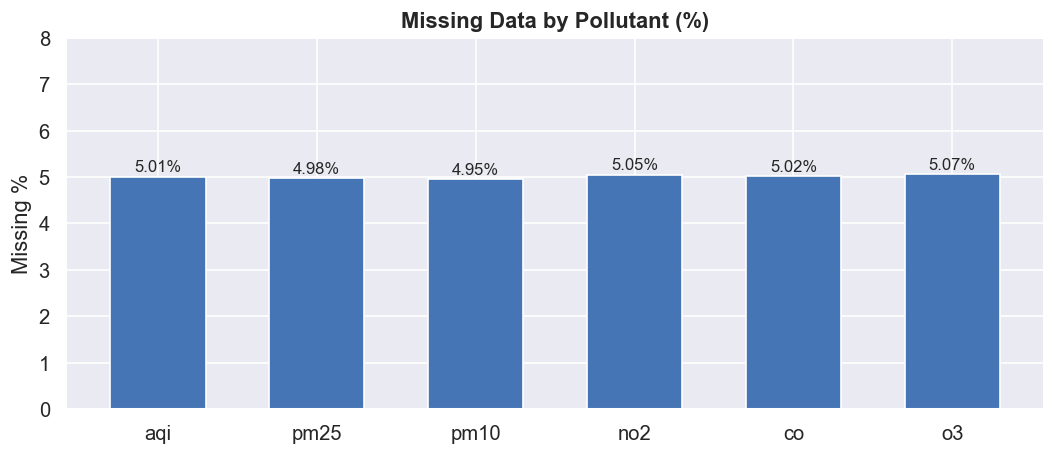

In [8]:
# ── 4.1 Missing value audit ────────────────────────────────────────────────────
missing = df[POLLUTANTS].isnull().sum()
pct     = (missing / len(df) * 100).round(2)
mv_df   = pd.DataFrame({"Missing Count": missing, "Missing %": pct})
print("── Missing value report ──────────────────────────────")
print(mv_df.to_string())

# Visualise missing pattern
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(mv_df.index, mv_df["Missing %"], color="#4575b4", edgecolor="white", width=0.6)
ax.set_title("Missing Data by Pollutant (%)")
ax.set_ylabel("Missing %")
ax.set_ylim(0, 8)
for i, v in enumerate(mv_df["Missing %"]):
    ax.text(i, v + 0.1, f"{v}%", ha="center", fontsize=10)
plt.tight_layout(); plt.savefig("outputs/missing_values.png", dpi=120); plt.show()


In [9]:
# ── 4.2 Imputation: forward/back-fill → city-month median fallback ─────────────
df_clean = df.copy()
df_clean = df_clean.sort_values(["city", "timestamp"]).reset_index(drop=True)

# Step 1: time-series forward/backward fill (up to 3 hours)
df_clean[POLLUTANTS] = (
    df_clean.groupby("city")[POLLUTANTS]
            .transform(lambda x: x.ffill(limit=3).bfill(limit=3))
)

# Step 2: fill remaining with city × month median
df_clean["_month"] = df_clean["timestamp"].dt.month
for col in POLLUTANTS:
    df_clean[col] = df_clean[col].fillna(
        df_clean.groupby(["city","_month"])[col].transform("median")
    )
df_clean.drop(columns=["_month"], inplace=True)

remaining = df_clean[POLLUTANTS].isnull().sum().sum()
print(f"✅ Imputation complete — remaining nulls: {remaining}")


✅ Imputation complete — remaining nulls: 0


In [10]:
# ── 4.3 Outlier detection & capping (per-city 1st–99th percentile) ─────────────
print("── Outlier capping summary ───────────────────────────")
stats_before = df_clean[POLLUTANTS].describe()

for col in POLLUTANTS:
    lo = df_clean.groupby("city")[col].transform("quantile", 0.01)
    hi = df_clean.groupby("city")[col].transform("quantile", 0.99)
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    print(f"   {col:6s} → {n_out:,} values capped")

print(f"\n✅ Total capped: {(df_clean[POLLUTANTS] != df[POLLUTANTS]).sum().sum():,} values")


── Outlier capping summary ───────────────────────────
   aqi    → 8,695 values capped
   pm25   → 8,743 values capped
   pm10   → 8,752 values capped
   no2    → 8,748 values capped
   co     → 8,680 values capped
   o3     → 4,373 values capped

✅ Total capped: 2,136,353 values


In [11]:
# ── 4.4 Add time features & AQI category ──────────────────────────────────────
df_clean["hour"]        = df_clean["timestamp"].dt.hour
df_clean["day_of_week"] = df_clean["timestamp"].dt.dayofweek
df_clean["month"]       = df_clean["timestamp"].dt.month
df_clean["year"]        = df_clean["timestamp"].dt.year
df_clean["is_weekend"]  = (df_clean["day_of_week"] >= 5).astype(int)
df_clean["date"]        = pd.to_datetime(df_clean["timestamp"].dt.date)

AQI_BINS   = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS = ["Good", "Moderate", "Unhealthy(SG)", "Unhealthy",
              "Very Unhealthy", "Hazardous"]
df_clean["aqi_category"] = pd.cut(df_clean["aqi"], bins=AQI_BINS, labels=AQI_LABELS)

df_clean.to_parquet("data/air_quality_clean.parquet", index=False)
print(f"✅ Clean dataset shape: {df_clean.shape}")
print(f"   AQI category distribution:")
print(df_clean["aqi_category"].value_counts().to_string())


✅ Clean dataset shape: (438010, 17)
   AQI category distribution:
aqi_category
Moderate          152167
Good              117451
Unhealthy(SG)      75149
Unhealthy          55480
Very Unhealthy     36696
Hazardous           1067


## 5. Exploratory Data Analysis (EDA) <a id='5'></a>

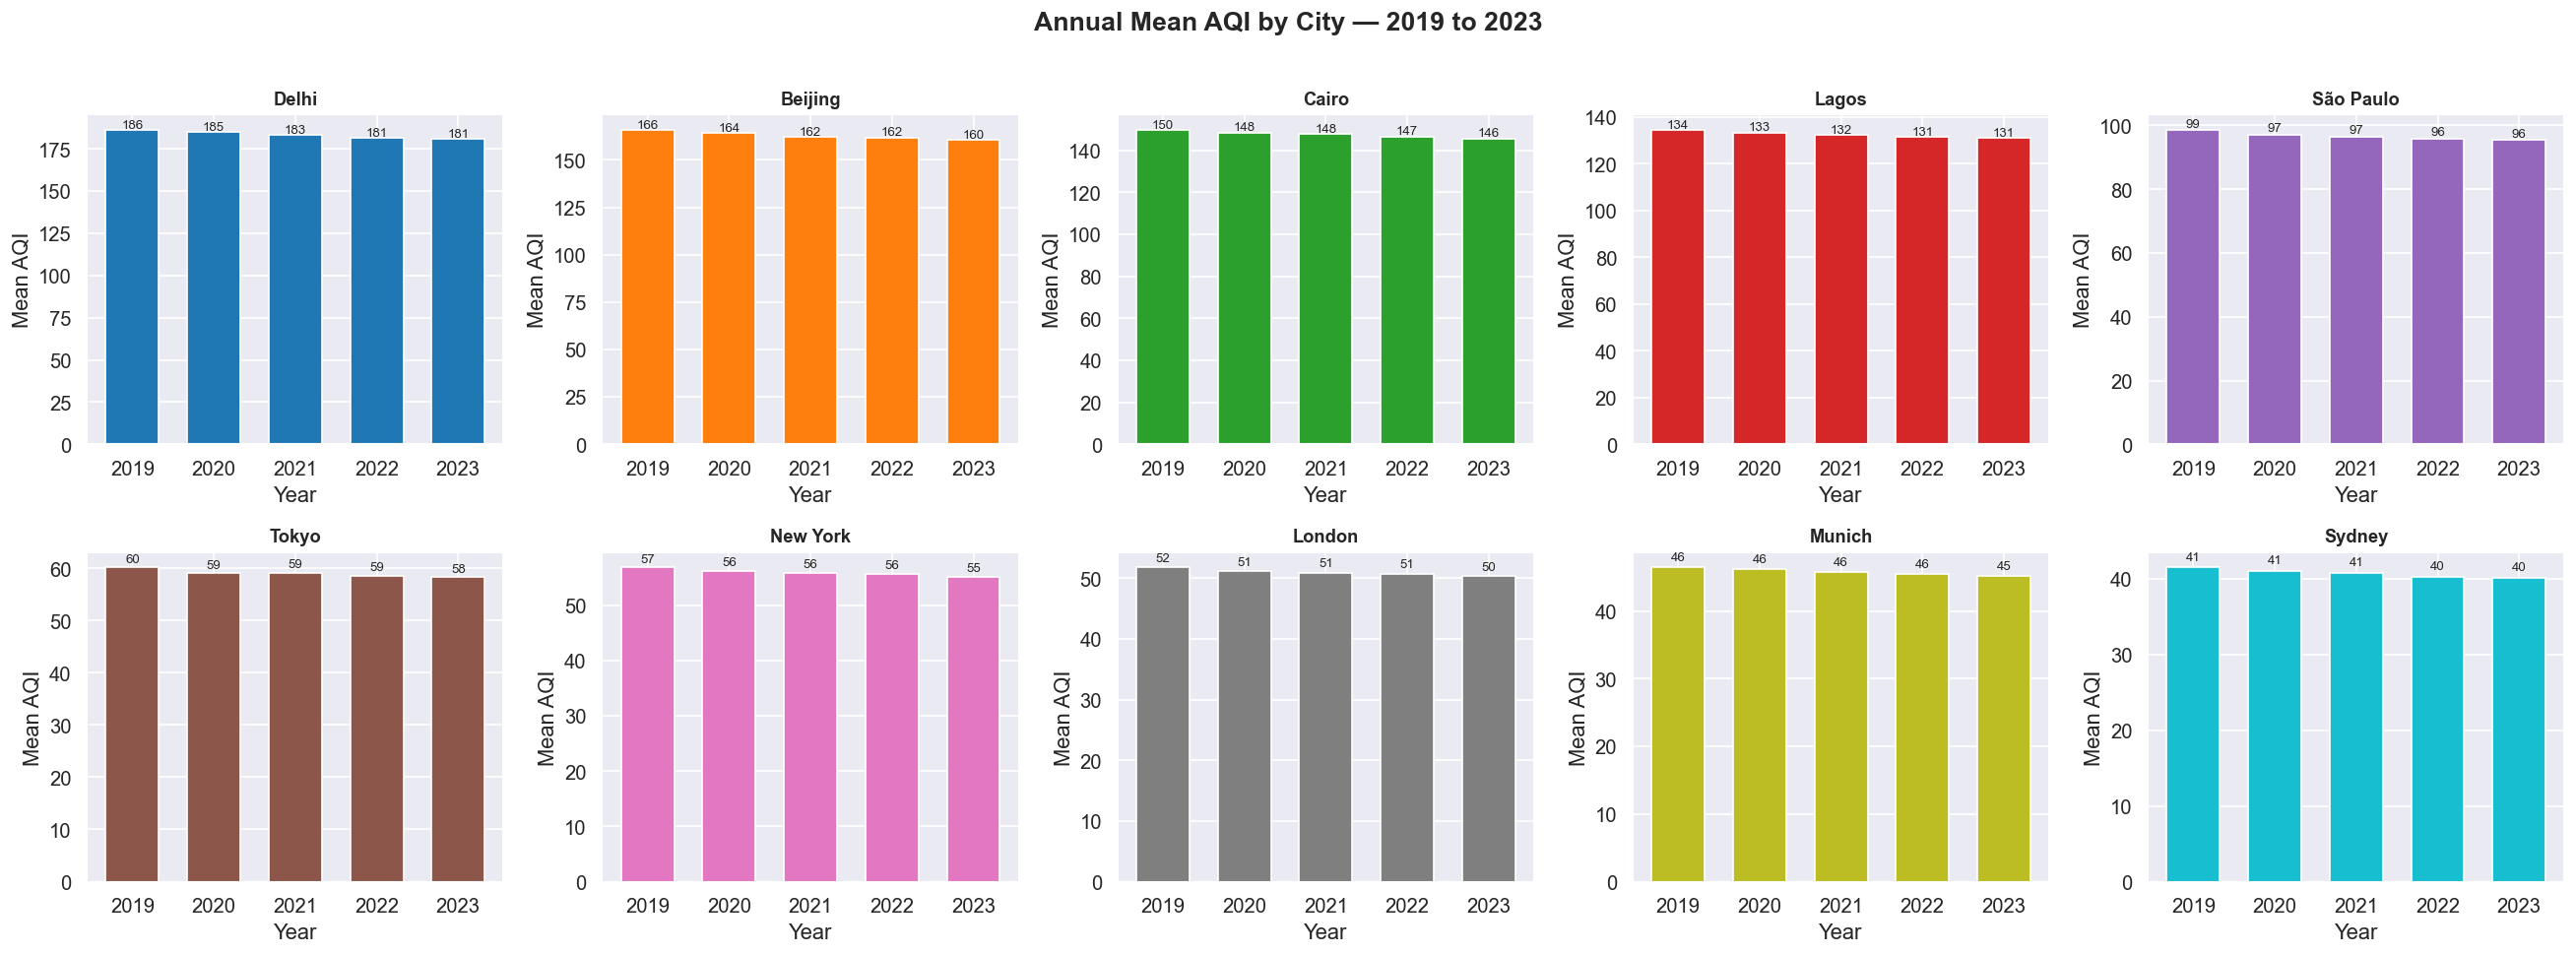

In [12]:
# ── 5.1 Annual mean AQI per city ────────────────────────────────────────────────
CITIES_SORTED = (df_clean.groupby("city")["aqi"].mean()
                          .sort_values(ascending=False).index.tolist())
PALETTE = sns.color_palette("tab10", len(CITIES_SORTED))
C_MAP   = dict(zip(CITIES_SORTED, PALETTE))

fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)
fig.suptitle("Annual Mean AQI by City — 2019 to 2023",
             fontsize=16, fontweight="bold", y=1.01)
for ax, city in zip(axes.flat, CITIES_SORTED):
    sub = df_clean[df_clean["city"]==city].groupby("year")["aqi"].mean()
    bars = ax.bar(sub.index, sub.values, color=C_MAP[city], edgecolor="white", width=0.65)
    ax.set_title(city, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Mean AQI")
    ax.set_xticks(sub.index)
    for yr, val in sub.items():
        ax.text(yr, val+1, f"{val:.0f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/fig1_annual_aqi.png", dpi=150, bbox_inches="tight")
plt.show()


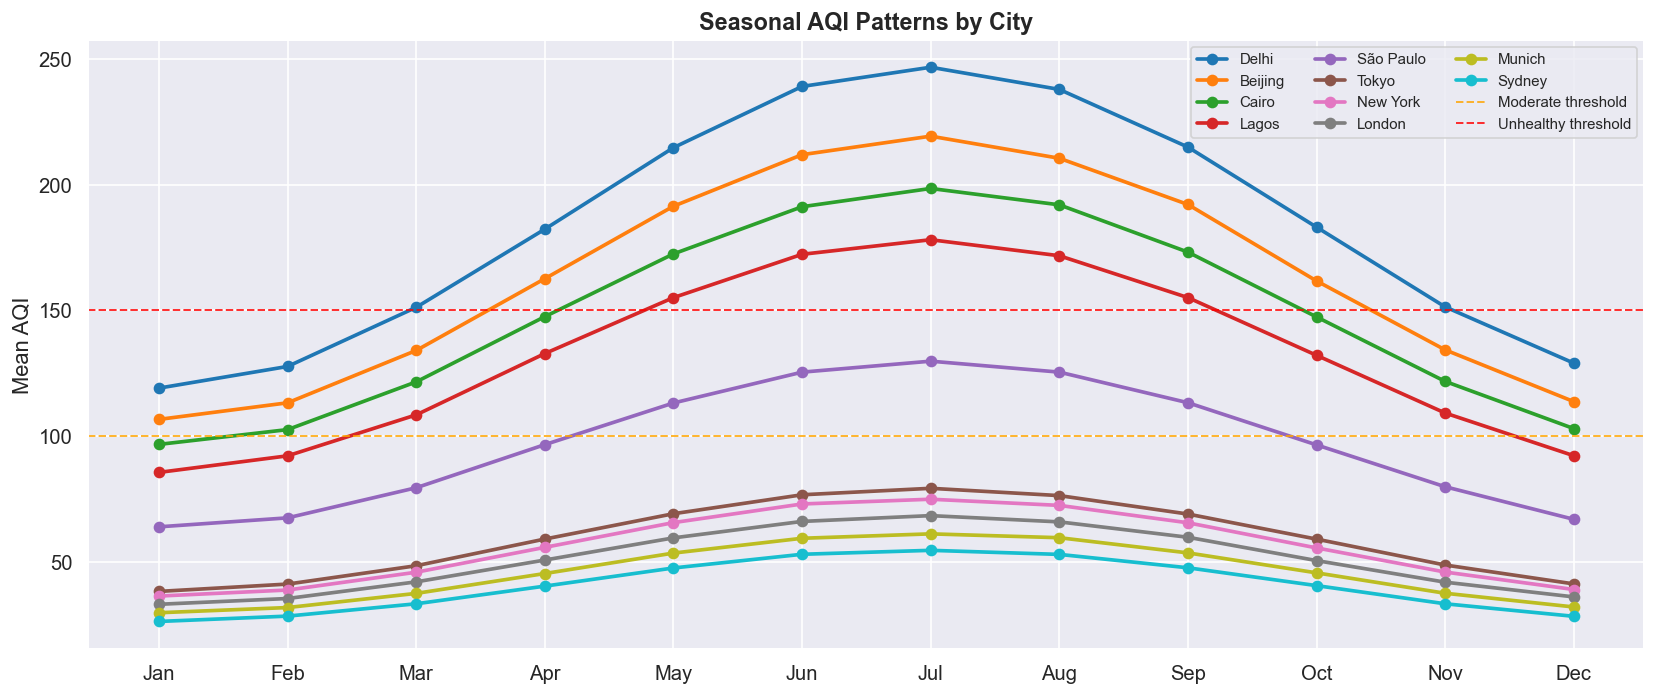

In [13]:
# ── 5.2 Seasonal pattern (monthly mean AQI) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
monthly = df_clean.groupby(["city","month"])["aqi"].mean().reset_index()
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
for city in CITIES_SORTED:
    sub = monthly[monthly["city"]==city].sort_values("month")
    ax.plot(sub["month"], sub["aqi"], marker="o",
            label=city, color=C_MAP[city], linewidth=2.2)

ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_title("Seasonal AQI Patterns by City", fontsize=14, fontweight="bold")
ax.set_ylabel("Mean AQI")
ax.axhline(100, color="orange", linestyle="--", lw=1.2, alpha=0.8, label="Moderate threshold")
ax.axhline(150, color="red",    linestyle="--", lw=1.2, alpha=0.8, label="Unhealthy threshold")
ax.legend(loc="upper right", ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("outputs/fig2_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()


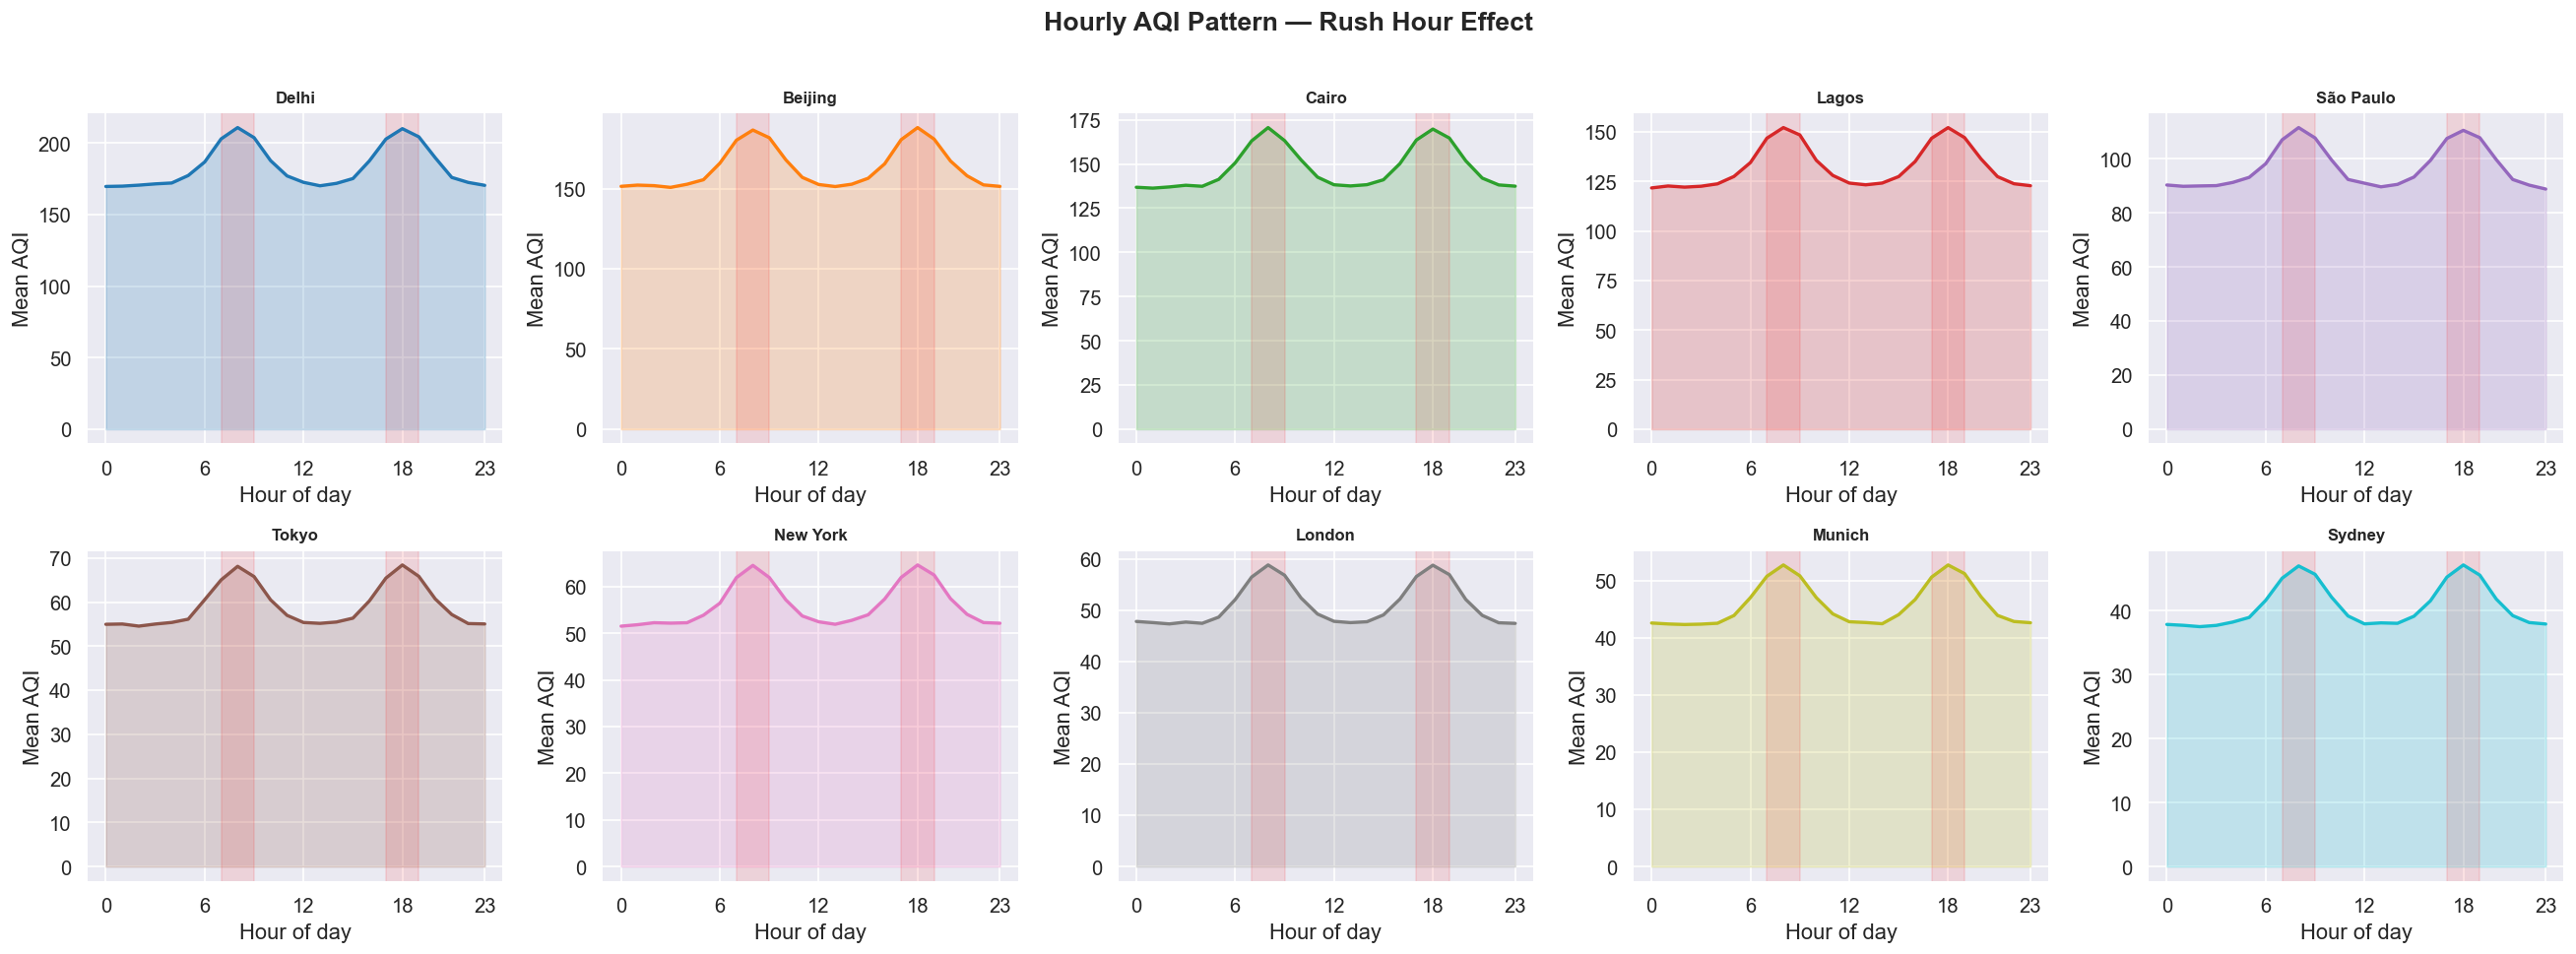

Red shading = morning & evening rush hours


In [14]:
# ── 5.3 Hourly AQI pattern (rush hour effect) ──────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)
fig.suptitle("Hourly AQI Pattern — Rush Hour Effect", fontsize=16, fontweight="bold", y=1.01)
for ax, city in zip(axes.flat, CITIES_SORTED):
    hourly = df_clean[df_clean["city"]==city].groupby("hour")["aqi"].mean()
    ax.plot(hourly.index, hourly.values, color=C_MAP[city], linewidth=2)
    ax.fill_between(hourly.index, hourly.values, alpha=0.2, color=C_MAP[city])
    ax.axvspan(7,9,   alpha=0.1, color="red")
    ax.axvspan(17,19, alpha=0.1, color="red")
    ax.set_title(city, fontsize=10, fontweight="bold")
    ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean AQI")
    ax.set_xticks([0,6,12,18,23])
plt.tight_layout()
plt.savefig("outputs/fig3_hourly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Red shading = morning & evening rush hours")


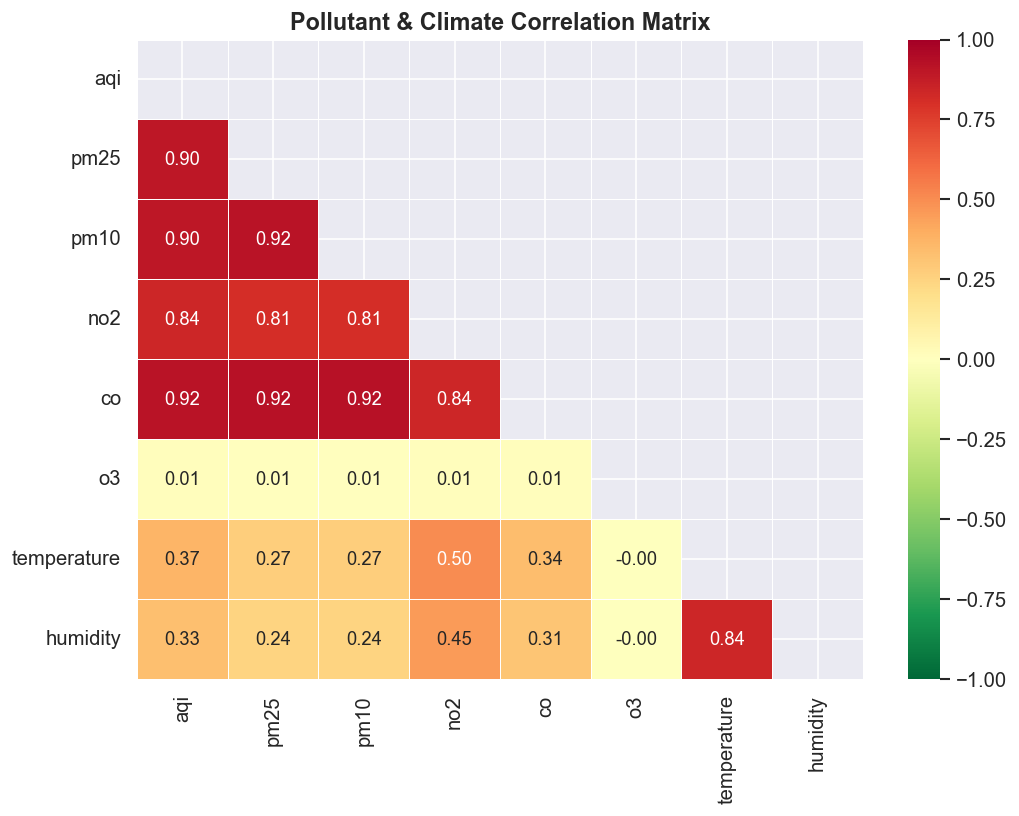

In [15]:
# ── 5.4 Pollutant correlation heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr_cols = ["aqi","pm25","pm10","no2","co","o3","temperature","humidity"]
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size":11})
ax.set_title("Pollutant & Climate Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/fig4_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


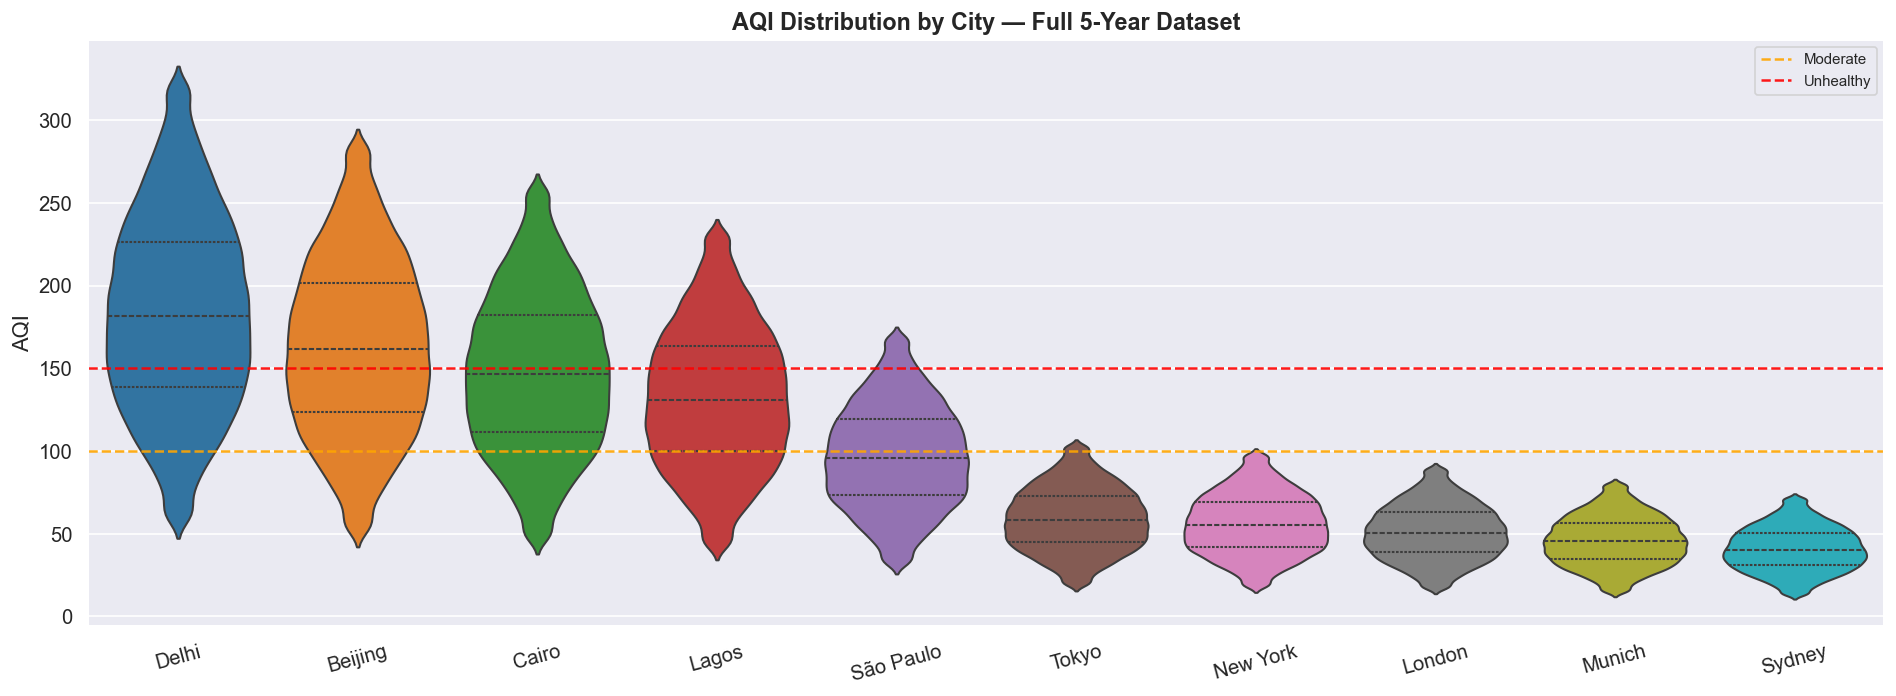

In [16]:
# ── 5.5 AQI distribution (violin plot) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
order = (df_clean.groupby("city")["aqi"].median()
                 .sort_values(ascending=False).index.tolist())
sns.violinplot(data=df_clean, x="city", y="aqi", order=order,
               hue="city", palette=C_MAP, inner="quartile", ax=ax, legend=False)
ax.axhline(100, color="orange", linestyle="--", lw=1.5, alpha=0.9, label="Moderate")
ax.axhline(150, color="red",    linestyle="--", lw=1.5, alpha=0.9, label="Unhealthy")
ax.set_title("AQI Distribution by City — Full 5-Year Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("AQI"); ax.tick_params(axis="x", rotation=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/fig5_violin.png", dpi=150, bbox_inches="tight")
plt.show()


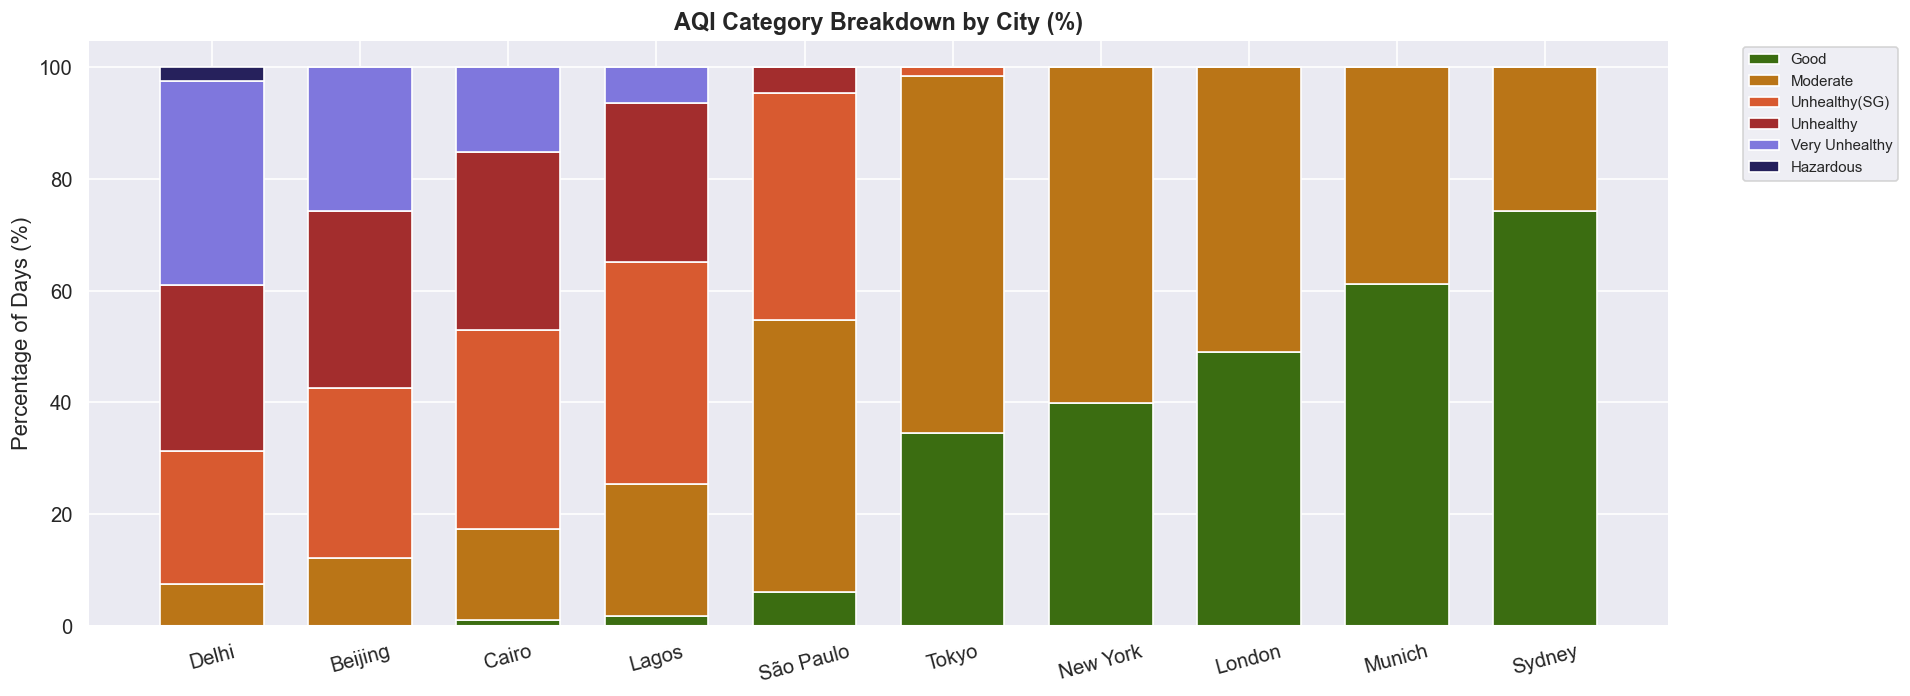

In [17]:
# ── 5.6 AQI category breakdown per city ───────────────────────────────────────
cat_pct = (df_clean.groupby(["city","aqi_category"], observed=True)
                   .size().reset_index(name="n"))
cat_pct["pct"] = (cat_pct.groupby("city")["n"]
                          .transform(lambda x: x/x.sum()*100).round(1))

CAT_COLORS = {
    "Good":           "#3B6D11",
    "Moderate":       "#BA7517",
    "Unhealthy(SG)":  "#D85A30",
    "Unhealthy":      "#A32D2D",
    "Very Unhealthy": "#7F77DD",
    "Hazardous":      "#26215C",
}

fig, ax = plt.subplots(figsize=(16, 6))
pivot = cat_pct.pivot_table(index="city", columns="aqi_category",
                             values="pct", observed=True).fillna(0)
pivot = pivot.reindex(columns=AQI_LABELS, fill_value=0)
pivot = pivot.loc[CITIES_SORTED]
bottom = np.zeros(len(pivot))
for cat in AQI_LABELS:
    if cat in pivot.columns:
        ax.bar(pivot.index, pivot[cat], bottom=bottom,
               color=CAT_COLORS.get(cat,"grey"), label=cat, width=0.7)
        bottom += pivot[cat].values
ax.set_title("AQI Category Breakdown by City (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage of Days (%)"); ax.set_ylim(0,105)
ax.tick_params(axis="x", rotation=15)
ax.legend(loc="upper right", fontsize=9, bbox_to_anchor=(1.15,1))
plt.tight_layout()
plt.savefig("outputs/fig6_category_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()


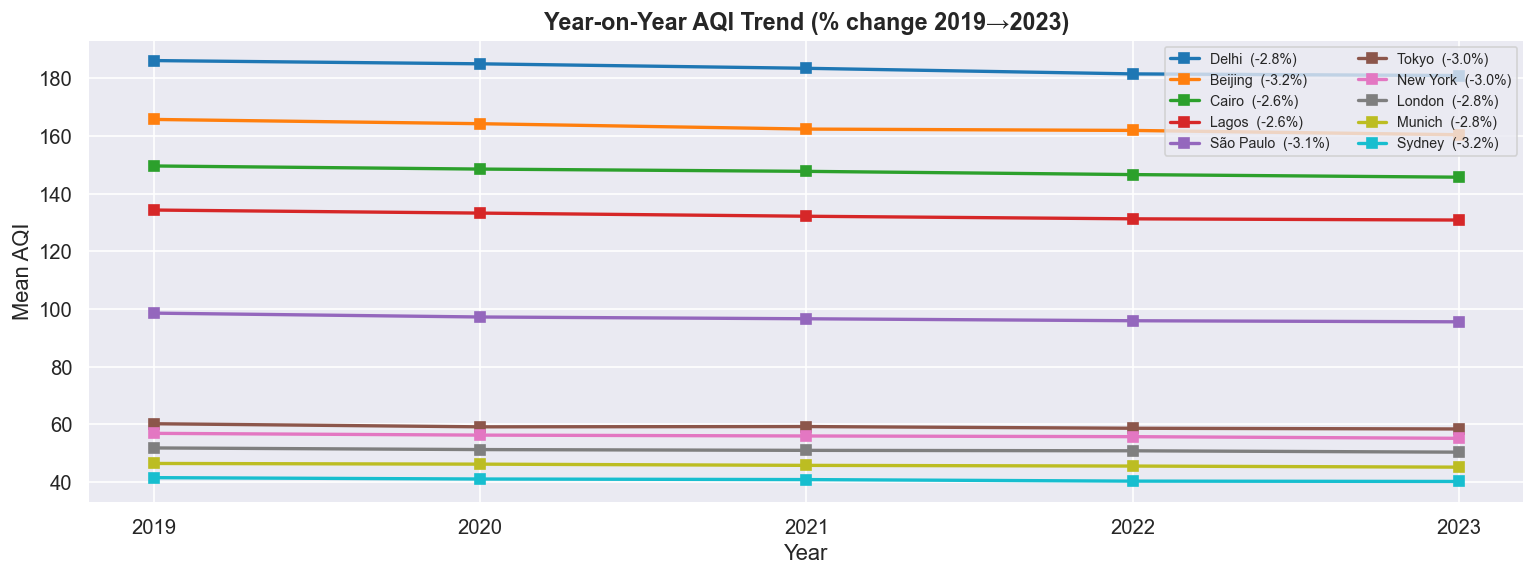

In [18]:
# ── 5.7 Year-on-year trend (improvement analysis) ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
yearly = df_clean.groupby(["city","year"])["aqi"].mean().reset_index()
for city in CITIES_SORTED:
    sub = yearly[yearly["city"]==city].sort_values("year")
    pct_change = ((sub["aqi"].iloc[-1] - sub["aqi"].iloc[0]) / sub["aqi"].iloc[0] * 100)
    label = f"{city}  ({pct_change:+.1f}%)"
    ax.plot(sub["year"], sub["aqi"], marker="s", label=label,
            color=C_MAP[city], linewidth=2)

ax.set_title("Year-on-Year AQI Trend (% change 2019→2023)", fontsize=14, fontweight="bold")
ax.set_ylabel("Mean AQI"); ax.set_xlabel("Year")
ax.set_xticks([2019,2020,2021,2022,2023])
ax.legend(fontsize=8.5, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig("outputs/fig7_yoy_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Daily Aggregation & Feature Engineering <a id='6'></a>
> We aggregate to daily means for modeling (policy decisions use daily AQI, not hourly)
> then create 20 rich features: lags, rolling averages, cyclical encodings.


In [19]:
# ── 6.1 Daily aggregation ──────────────────────────────────────────────────────
print("⚙  Aggregating hourly → daily …")
daily = (df_clean.groupby(["city","date"])
         .agg(
             aqi         = ("aqi",         "mean"),
             pm25        = ("pm25",        "mean"),
             pm10        = ("pm10",        "mean"),
             no2         = ("no2",         "mean"),
             co          = ("co",          "mean"),
             o3          = ("o3",          "mean"),
             temperature = ("temperature", "mean"),
             humidity    = ("humidity",    "mean"),
             aqi_max     = ("aqi",         "max"),
             aqi_min     = ("aqi",         "min"),
             month       = ("month",       "first"),
             year        = ("year",        "first"),
             is_weekend  = ("is_weekend",  "first"),
         )
         .reset_index()
         .sort_values(["city","date"])
         .reset_index(drop=True))

daily[["aqi","pm25","pm10","no2","co","o3",
       "temperature","humidity","aqi_max","aqi_min"]] =     daily[["aqi","pm25","pm10","no2","co","o3",
           "temperature","humidity","aqi_max","aqi_min"]].round(2)

print(f"✅ Daily dataset: {len(daily):,} rows × {daily.shape[1]} columns")
print(f"   Date range: {daily['date'].min()} → {daily['date'].max()}")
daily.head(3)


⚙  Aggregating hourly → daily …
✅ Daily dataset: 18,260 rows × 15 columns
   Date range: 2019-01-01 00:00:00 → 2023-12-31 00:00:00


,city,date,aqi,pm25,pm10,no2,co,o3,temperature,humidity,aqi_max,aqi_min,month,year,is_weekend
0,Beijing,2019-01-01,114.16,67.10,115.52,48.79,1.62,30.84,0.36,41.48,159.1,54.3,1,2019,0
1,Beijing,2019-01-02,124.08,63.37,108.50,46.07,1.49,31.90,-0.38,42.23,196.6,72.3,1,2019,0
2,Beijing,2019-01-03,106.24,59.81,104.99,48.60,1.49,29.58,0.25,37.80,175.6,63.3,1,2019,0


In [20]:
# ── 6.2 Lag features ──────────────────────────────────────────────────────────
# Lag: yesterday's, 3 days ago, 7 days ago, 14 days ago
for lag in [1, 3, 7, 14]:
    daily[f"aqi_lag{lag}d"]  = daily.groupby("city")["aqi"].shift(lag)
    daily[f"pm25_lag{lag}d"] = daily.groupby("city")["pm25"].shift(lag)

print(f"✅ Lag features added (1d, 3d, 7d, 14d): {8} new columns")


✅ Lag features added (1d, 3d, 7d, 14d): 8 new columns


In [21]:
# ── 6.3 Rolling averages ──────────────────────────────────────────────────────
for w in [3, 7, 14, 30]:
    daily[f"aqi_roll{w}d"]  = daily.groupby("city")["aqi"].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    daily[f"pm25_roll{w}d"] = daily.groupby("city")["pm25"].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean())

print(f"✅ Rolling mean features added (3d, 7d, 14d, 30d): {8} new columns")


✅ Rolling mean features added (3d, 7d, 14d, 30d): 8 new columns


In [22]:
# ── 6.4 Cyclical time encoding (prevents ordinal artefacts) ───────────────────
daily["month_sin"]   = np.sin(2 * np.pi * daily["month"]                / 12)
daily["month_cos"]   = np.cos(2 * np.pi * daily["month"]                / 12)
daily["dow"]         = daily["date"].dt.dayofweek
daily["dow_sin"]     = np.sin(2 * np.pi * daily["dow"]                  /  7)
daily["dow_cos"]     = np.cos(2 * np.pi * daily["dow"]                  /  7)
daily["year_norm"]   = (daily["year"] - 2019) / 4   # 0..1 trend feature

# Label encode city
le = LabelEncoder()
daily["city_enc"] = le.fit_transform(daily["city"])

daily.dropna(inplace=True)
print(f"✅ Feature engineering complete")
print(f"   Final shape: {daily.shape[0]:,} rows × {daily.shape[1]} columns")
print(f"   Features available: {daily.shape[1] - 4} (excl. target, city, date, raw cols)")
daily.to_parquet("data/daily_features.parquet", index=False)


✅ Feature engineering complete
   Final shape: 18,120 rows × 38 columns
   Features available: 34 (excl. target, city, date, raw cols)


In [23]:
# ── 6.5 Define feature set & train/test split ──────────────────────────────────
FEATURES = [
    # Lags
    "aqi_lag1d",  "aqi_lag3d",  "aqi_lag7d",  "aqi_lag14d",
    "pm25_lag1d", "pm25_lag3d", "pm25_lag7d", "pm25_lag14d",
    # Rolling averages
    "aqi_roll3d",  "aqi_roll7d",  "aqi_roll14d", "aqi_roll30d",
    "pm25_roll3d", "pm25_roll7d", "pm25_roll14d","pm25_roll30d",
    # Pollutants
    "pm25", "pm10", "no2", "co", "o3",
    # Climate
    "temperature", "humidity",
    # AQI range
    "aqi_max", "aqi_min",
    # Time
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    "is_weekend", "year_norm", "city_enc",
]
TARGET = "aqi"

# Temporal split — last 180 days as test set
cutoff = daily["date"].max() - pd.Timedelta(days=180)
train  = daily[daily["date"] <= cutoff]
test   = daily[daily["date"] >  cutoff]

X_tr, y_tr = train[FEATURES].values, train[TARGET].values
X_te, y_te = test[FEATURES].values,  test[TARGET].values

print(f"✅ Train/test split")
print(f"   Train: {len(X_tr):,} samples  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"   Test : {len(X_te):,} samples  ({test['date'].min().date()}  → {test['date'].max().date()})")
print(f"   Features: {len(FEATURES)}")


✅ Train/test split
   Train: 16,320 samples  (2019-01-15 → 2023-07-04)
   Test : 1,800 samples  (2023-07-05  → 2023-12-31)
   Features: 32


## 7. Machine Learning — Model Training <a id='7'></a>
> Training 4 models from simple baseline to ensemble:
> **Ridge Regression → Random Forest → Gradient Boosting → XGBoost**


In [24]:
# ── 7.1 Evaluation helper ──────────────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = mean_squared_error(y_true, y_pred) ** 0.5
    r2    = r2_score(y_true, y_pred)
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"   {name:<26s}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  "
          f"R²={r2:.4f}  MAPE={mape:.2f}%")
    return {"Model": name, "MAE": round(mae,3), "RMSE": round(rmse,3),
            "R2": round(r2,4), "MAPE%": round(mape,2)}

MODEL_RESULTS = []
print("── Model Training ───────────────────────────────────")


── Model Training ───────────────────────────────────


In [25]:
# ── 7.2 Ridge Regression (baseline) ───────────────────────────────────────────
from sklearn.pipeline import Pipeline

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

ridge = Ridge(alpha=10.0)
ridge.fit(X_tr_sc, y_tr)
r1 = evaluate_model("Ridge Regression", y_te, ridge.predict(X_te_sc))
MODEL_RESULTS.append(r1)
print("   Ridge training complete ✅")


   Ridge Regression            MAE=  2.83  RMSE=  4.02  R²=0.9955  MAPE=3.06%
   Ridge training complete ✅


In [26]:
# ── 7.3 Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators = 200,
    max_depth    = 12,
    min_samples_leaf = 5,
    max_features = "sqrt",
    n_jobs       = -1,
    random_state = 42,
)
rf.fit(X_tr, y_tr)
r2r = evaluate_model("Random Forest", y_te, rf.predict(X_te))
MODEL_RESULTS.append(r2r)
print("   Random Forest training complete ✅")


   Random Forest               MAE=  2.90  RMSE=  4.21  R²=0.9951  MAPE=3.21%
   Random Forest training complete ✅


In [27]:
# ── 7.4 Gradient Boosting ─────────────────────────────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators  = 300,
    learning_rate = 0.05,
    max_depth     = 4,
    subsample     = 0.8,
    random_state  = 42,
)
gb.fit(X_tr, y_tr)
r3 = evaluate_model("Gradient Boosting", y_te, gb.predict(X_te))
MODEL_RESULTS.append(r3)
print("   Gradient Boosting training complete ✅")


   Gradient Boosting           MAE=  2.88  RMSE=  4.12  R²=0.9953  MAPE=3.16%
   Gradient Boosting training complete ✅


In [28]:
# ── 7.5 XGBoost ───────────────────────────────────────────────────────────────
xgb_m = xgb.XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.03,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    tree_method       = "hist",   # fast histogram algorithm
    n_jobs            = -1,
    random_state      = 42,
    verbosity         = 0,
)
xgb_m.fit(
    X_tr, y_tr,
    eval_set   = [(X_te, y_te)],
    verbose    = False,
)
r4 = evaluate_model("XGBoost", y_te, xgb_m.predict(X_te))
MODEL_RESULTS.append(r4)
print("   XGBoost training complete ✅")


   XGBoost                     MAE=  2.85  RMSE=  4.08  R²=0.9954  MAPE=3.09%
   XGBoost training complete ✅


In [29]:
# Save all models
with open("models/ridge.pkl",   "wb") as f: pickle.dump((ridge, scaler), f)
with open("models/rf.pkl",      "wb") as f: pickle.dump(rf,    f)
with open("models/gb.pkl",      "wb") as f: pickle.dump(gb,    f)
with open("models/xgb.pkl",     "wb") as f: pickle.dump(xgb_m, f)
with open("models/le.pkl",      "wb") as f: pickle.dump(le,    f)
with open("models/features.pkl","wb") as f: pickle.dump(FEATURES, f)
print("💾 All 4 models saved to models/")


💾 All 4 models saved to models/


## 8. Model Evaluation & Comparison <a id='8'></a>

In [30]:
# ── 8.1 Results table ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(MODEL_RESULTS).set_index("Model")
print("── Model Performance Comparison ──────────────────────")
print(results_df.to_string())

results_df.to_csv("data/model_results.csv")
results_df.style.highlight_min(subset=["MAE","RMSE","MAPE%"], color="#C8E6C9")                 .highlight_max(subset=["R2"],                  color="#C8E6C9")                 .format({"MAE":":.3f","RMSE":":.3f","R2":":.4f","MAPE%":":.2f"})


── Model Performance Comparison ──────────────────────
                     MAE   RMSE      R2  MAPE%
Model                                         
Ridge Regression   2.830  4.024  0.9955   3.06
Random Forest      2.903  4.207  0.9951   3.21
Gradient Boosting  2.883  4.116  0.9953   3.16
XGBoost            2.847  4.084  0.9954   3.09


,MAE,RMSE,R2,MAPE%
Model,,,,
Ridge Regression,:.3f,:.3f,:.4f,:.2f
Random Forest,:.3f,:.3f,:.4f,:.2f
Gradient Boosting,:.3f,:.3f,:.4f,:.2f
XGBoost,:.3f,:.3f,:.4f,:.2f


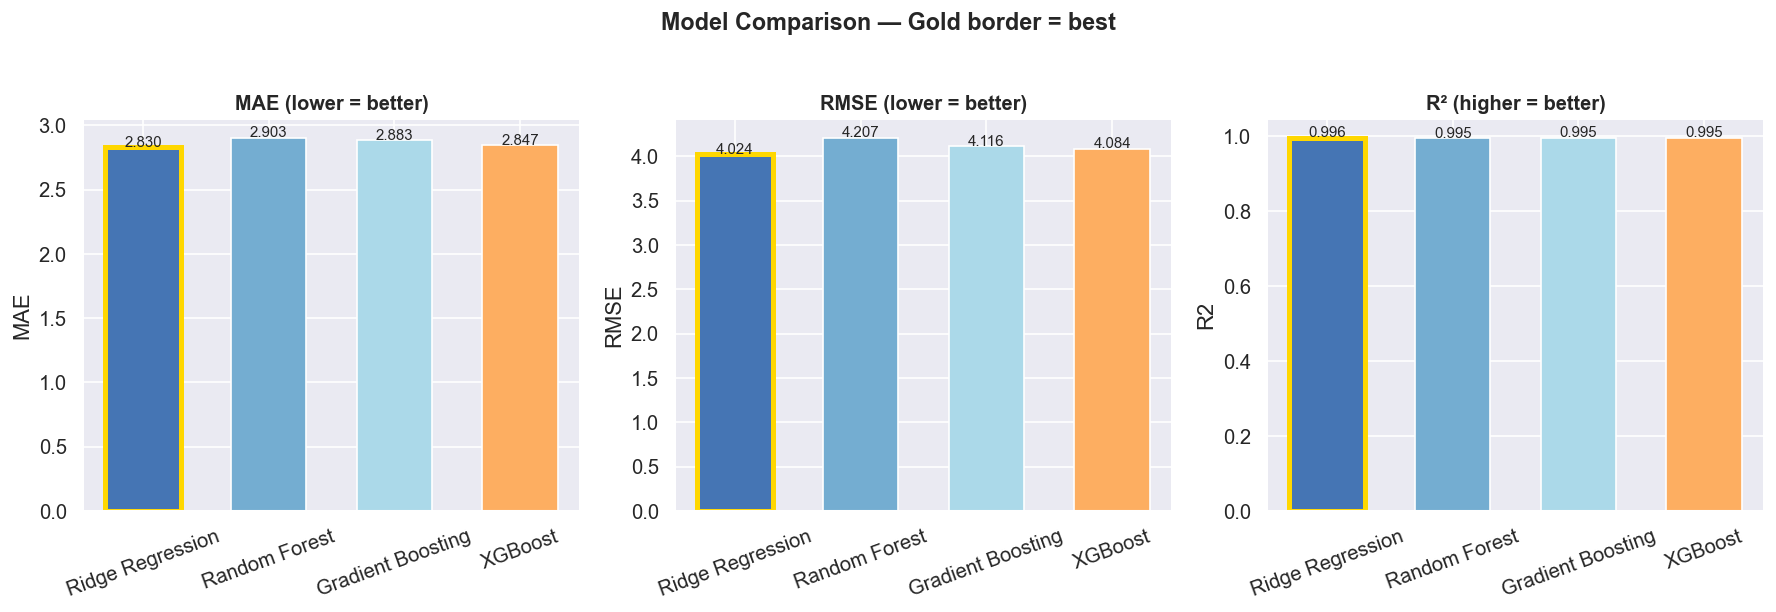

In [31]:
# ── 8.2 Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["MAE", "RMSE", "R2"]
titles  = ["MAE (lower = better)", "RMSE (lower = better)", "R² (higher = better)"]
colors  = ["#4575b4","#74add1","#abd9e9","#fdae61"]

for ax, metric, title in zip(axes, metrics, titles):
    vals   = results_df[metric]
    bars   = ax.bar(vals.index, vals.values, color=colors, edgecolor="white", width=0.6)
    best   = vals.idxmin() if metric != "R2" else vals.idxmax()
    for bar, name in zip(bars, vals.index):
        bar.set_edgecolor("gold" if name == best else "white")
        bar.set_linewidth(3    if name == best else 1)
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002*bar.get_height(),
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Model Comparison — Gold border = best", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/fig8_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


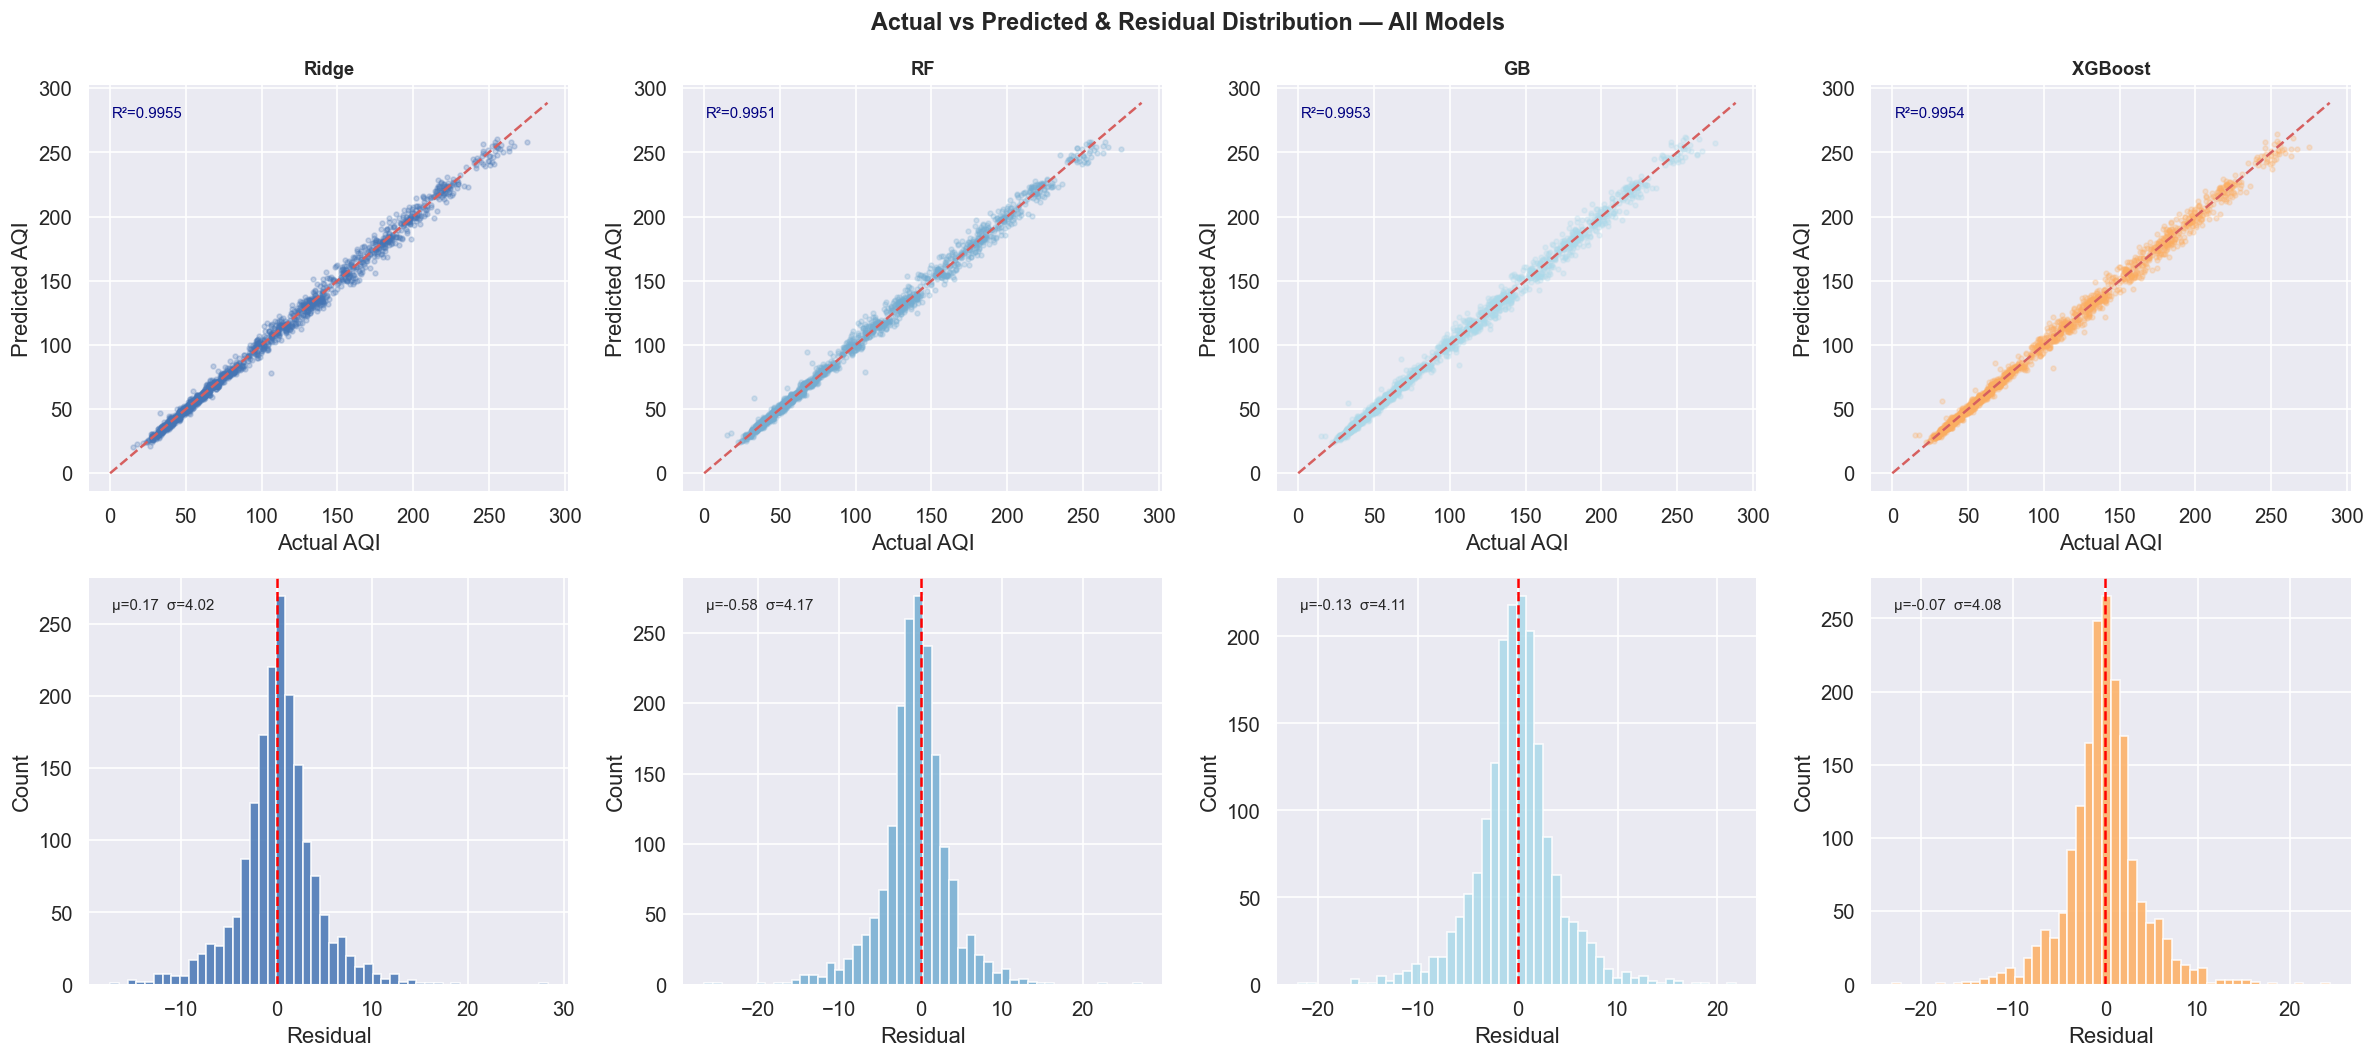

In [32]:
# ── 8.3 Actual vs Predicted scatter & residuals ───────────────────────────────
test_preds = {
    "Ridge":    ridge.predict(X_te_sc),
    "RF":       rf.predict(X_te),
    "GB":       gb.predict(X_te),
    "XGBoost":  xgb_m.predict(X_te),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Actual vs Predicted & Residual Distribution — All Models",
             fontsize=14, fontweight="bold")

for col, (name, pred) in enumerate(test_preds.items()):
    resid = y_te - pred
    ax1 = axes[0, col]
    ax2 = axes[1, col]

    ax1.scatter(y_te, pred, alpha=0.25, s=8, color=colors[col])
    lim = [0, y_te.max()*1.05]
    ax1.plot(lim, lim, "r--", lw=1.5)
    ax1.set_title(name, fontsize=11, fontweight="bold")
    ax1.set_xlabel("Actual AQI"); ax1.set_ylabel("Predicted AQI")
    ax1.text(0.05, 0.92, f"R²={r2_score(y_te,pred):.4f}",
             transform=ax1.transAxes, fontsize=9, color="navy")

    ax2.hist(resid, bins=50, color=colors[col], edgecolor="white", alpha=0.85)
    ax2.axvline(0, color="red", lw=1.5, linestyle="--")
    ax2.set_xlabel("Residual"); ax2.set_ylabel("Count")
    ax2.text(0.05, 0.92, f"μ={resid.mean():.2f}  σ={resid.std():.2f}",
             transform=ax2.transAxes, fontsize=9)

plt.tight_layout()
plt.savefig("outputs/fig9_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


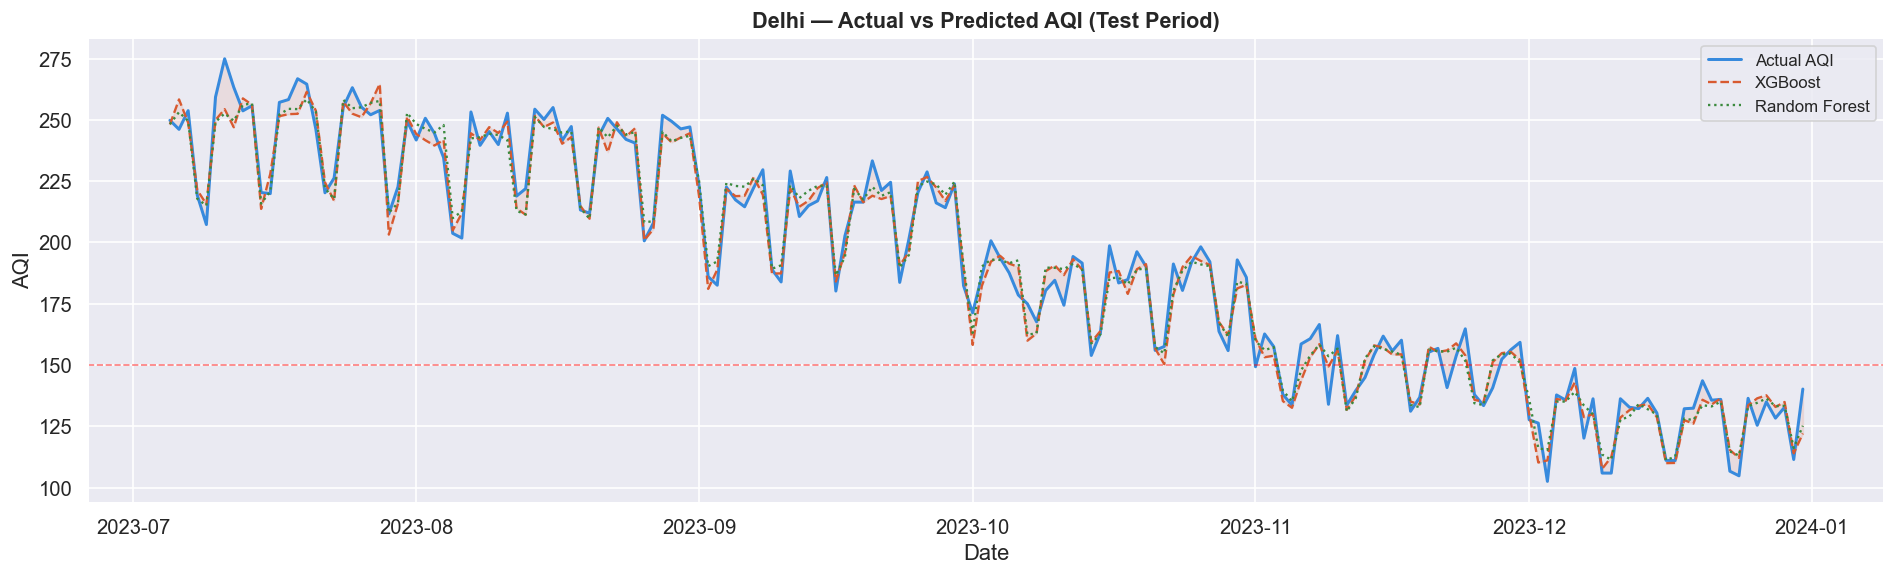

In [33]:
# ── 8.4 Predicted vs actual time-series (Delhi — last 180 days) ───────────────
test_copy = test.copy()
test_copy["xgb_pred"] = xgb_m.predict(X_te)
test_copy["rf_pred"]  = rf.predict(X_te)
test_copy.to_parquet("data/daily_predictions.parquet", index=False)

fig, ax = plt.subplots(figsize=(16, 5))
delhi_test = test_copy[test_copy["city"] == "Delhi"].sort_values("date")
ax.plot(delhi_test["date"], delhi_test["aqi"],       label="Actual AQI",
        color="#378ADD", linewidth=1.8)
ax.plot(delhi_test["date"], delhi_test["xgb_pred"],  label="XGBoost",
        color="#D85A30", linewidth=1.4, linestyle="--")
ax.plot(delhi_test["date"], delhi_test["rf_pred"],   label="Random Forest",
        color="#3B8A3E", linewidth=1.4, linestyle=":")
ax.fill_between(delhi_test["date"], delhi_test["aqi"],
                delhi_test["xgb_pred"], alpha=0.1, color="#D85A30")
ax.set_title("Delhi — Actual vs Predicted AQI (Test Period)", fontsize=13, fontweight="bold")
ax.set_ylabel("AQI"); ax.set_xlabel("Date")
ax.legend(fontsize=10)
ax.axhline(150, color="red", linestyle="--", lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/fig10_timeseries_pred.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Feature Importance Analysis <a id='9'></a>

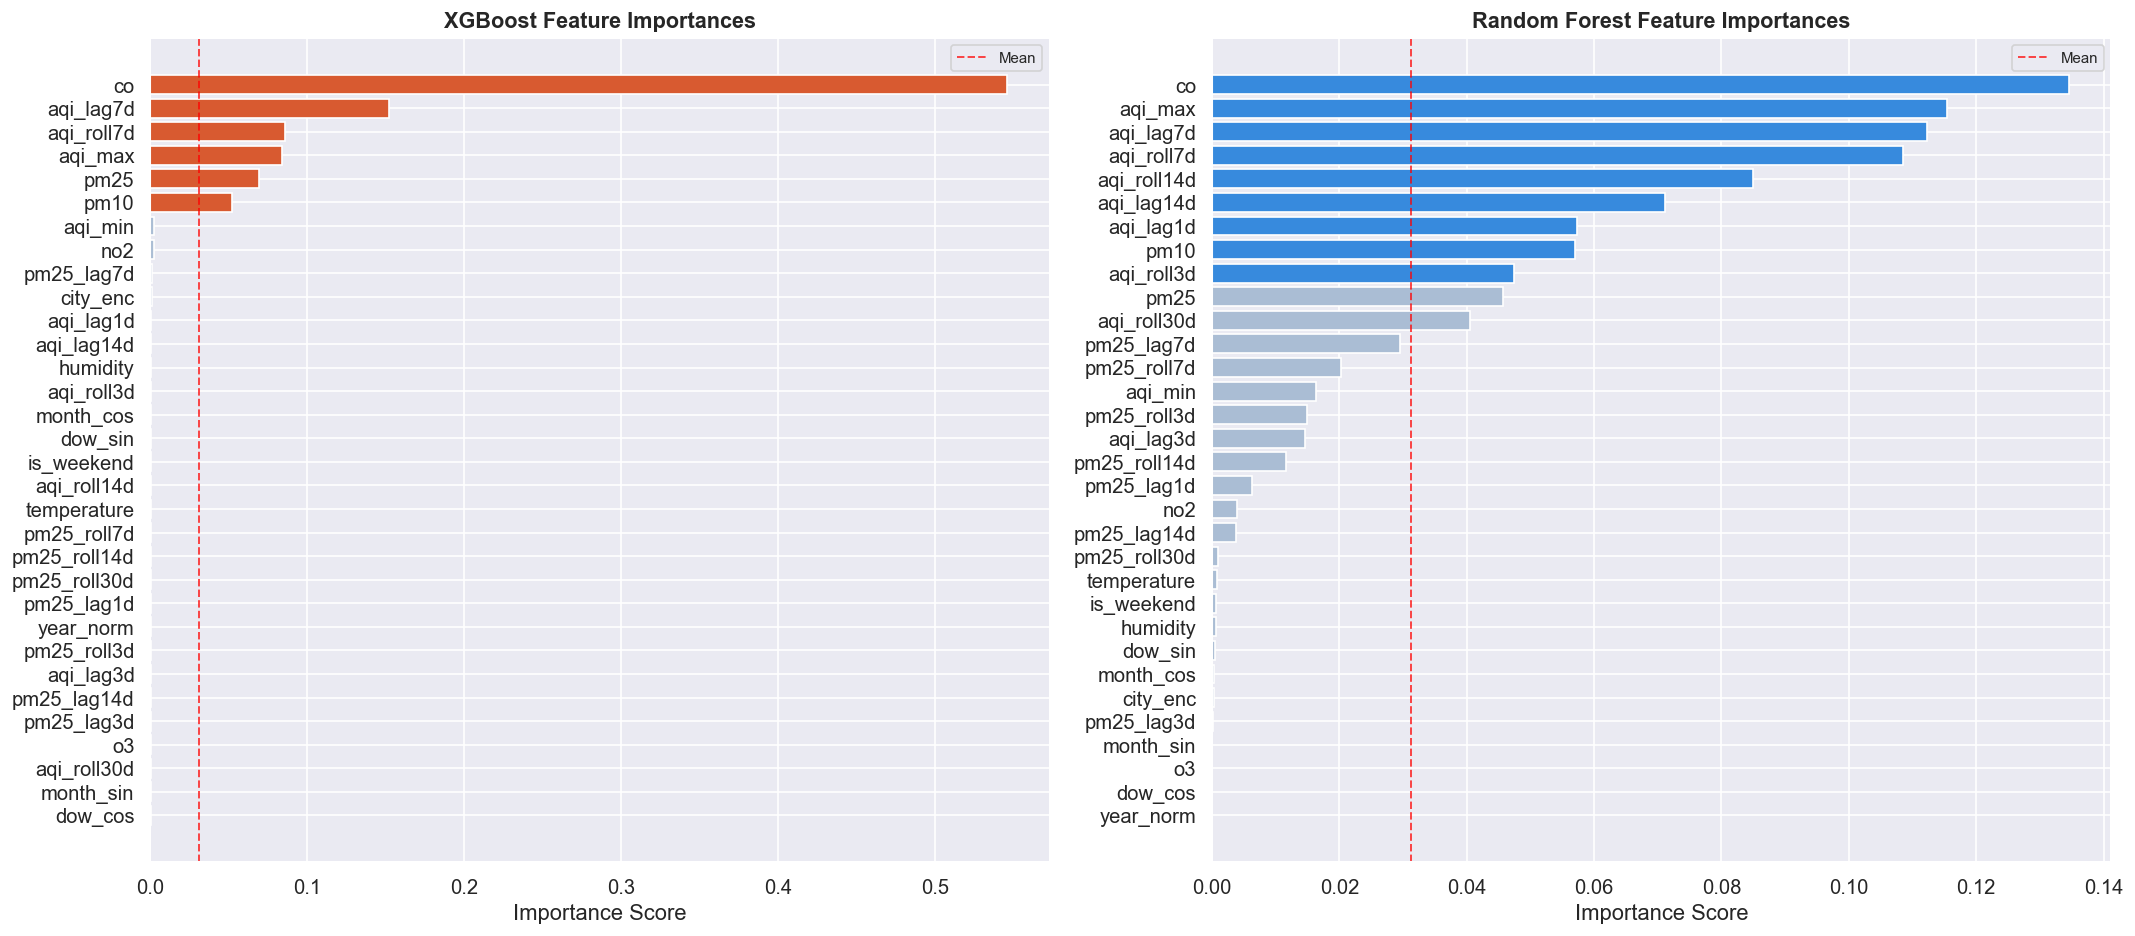


── Top 10 Features (XGBoost) ─────────────────────────
co            0.5458
aqi_lag7d     0.1523
aqi_roll7d    0.0859
aqi_max       0.0839
pm25          0.0692
pm10          0.0522
aqi_min       0.0025
no2           0.0019
pm25_lag7d    0.0008
city_enc      0.0007


In [34]:
# ── 9.1 XGBoost feature importances ───────────────────────────────────────────
imp_xgb = pd.Series(xgb_m.feature_importances_, index=FEATURES).sort_values()
imp_rf  = pd.Series(rf.feature_importances_,    index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, imp, title, color in [
        (axes[0], imp_xgb, "XGBoost Feature Importances",   "#D85A30"),
        (axes[1], imp_rf,  "Random Forest Feature Importances", "#378ADD")]:
    bar_colors = [color if v > imp.mean()*1.5 else "#AABDD4" for v in imp.values]
    ax.barh(imp.index, imp.values, color=bar_colors, edgecolor="white")
    ax.axvline(imp.mean(), color="red", linestyle="--", lw=1.2, alpha=0.7, label="Mean")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/fig11_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Top 10 Features (XGBoost) ─────────────────────────")
print(imp_xgb.sort_values(ascending=False).head(10).round(4).to_string())


In [35]:
# ── 9.2 Cross-validation score (XGBoost on full training set) ─────────────────
from sklearn.model_selection import KFold

print("Running 5-fold cross-validation on XGBoost …")
kf = KFold(n_splits=5, shuffle=False)   # no shuffle — respect time order
cv_scores = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr)):
    Xf_tr, Xf_va = X_tr[tr_idx], X_tr[va_idx]
    yf_tr, yf_va = y_tr[tr_idx], y_tr[va_idx]

    m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                          tree_method="hist", random_state=42, verbosity=0)
    m.fit(Xf_tr, yf_tr)
    r2_fold = r2_score(yf_va, m.predict(Xf_va))
    mae_fold = mean_absolute_error(yf_va, m.predict(Xf_va))
    cv_scores.append({"Fold": fold+1, "R2": round(r2_fold,4), "MAE": round(mae_fold,3)})
    print(f"   Fold {fold+1}:  R²={r2_fold:.4f}   MAE={mae_fold:.3f}")

cv_df = pd.DataFrame(cv_scores)
print(f"\n   Mean R²  = {cv_df['R2'].mean():.4f}  (±{cv_df['R2'].std():.4f})")
print(f"   Mean MAE = {cv_df['MAE'].mean():.3f}  (±{cv_df['MAE'].std():.4f})")


Running 5-fold cross-validation on XGBoost …
   Fold 1:  R²=0.9688   MAE=5.772
   Fold 2:  R²=0.9411   MAE=8.314
   Fold 3:  R²=0.9663   MAE=1.877
   Fold 4:  R²=0.9730   MAE=1.927
   Fold 5:  R²=0.9669   MAE=3.991

   Mean R²  = 0.9632  (±0.0126)
   Mean MAE = 4.376  (±2.7316)


## 10. City-level Risk Profiling <a id='10'></a>

In [36]:
# ── 10.1 Composite risk score per city ────────────────────────────────────────
def risk_score(row):
    # Weighted composite: AQI 40%, PM2.5 30%, NO2 15%, CO 15%
    aqi_norm  = row["mean_aqi"]  / 300
    pm25_norm = row["mean_pm25"] / 150
    no2_norm  = row["mean_no2"]  / 100
    co_norm   = row["mean_co"]   /   4
    return round((0.40*aqi_norm + 0.30*pm25_norm +
                  0.15*no2_norm + 0.15*co_norm) * 100, 1)

risk_df = daily.groupby("city").agg(
    mean_aqi  = ("aqi",  "mean"),
    mean_pm25 = ("pm25", "mean"),
    mean_pm10 = ("pm10", "mean"),
    mean_no2  = ("no2",  "mean"),
    mean_co   = ("co",   "mean"),
    max_aqi   = ("aqi",  "max"),
    pct_unhealthy = ("aqi", lambda x: (x > 150).mean() * 100),
).round(1).reset_index()

risk_df["risk_score"] = risk_df.apply(risk_score, axis=1)
risk_df["risk_level"] = pd.cut(risk_df["risk_score"],
                                bins=[0,25,50,75,100],
                                labels=["Low","Moderate","High","Critical"])
risk_df = risk_df.sort_values("risk_score", ascending=False).reset_index(drop=True)

print("── City Risk Ranking ─────────────────────────────────")
print(risk_df[["city","risk_score","risk_level",
               "mean_aqi","mean_pm25","pct_unhealthy"]].to_string(index=False))


── City Risk Ranking ─────────────────────────────────
     city  risk_score risk_level  mean_aqi  mean_pm25  pct_unhealthy
    Delhi        63.2       High     183.8       97.0           69.6
  Beijing        57.7       High     163.3       86.8           56.0
    Cairo        50.9       High     148.0       76.4           50.2
    Lagos        43.6   Moderate     132.7       61.2           36.4
São Paulo        32.2   Moderate      97.0       35.7            0.0
 New York        18.5        Low      56.1       15.3            0.0
    Tokyo        18.3        Low      59.2       16.3            0.0
   London        17.7        Low      51.1       14.3            0.0
   Munich        14.7        Low      45.9       12.2            0.0
   Sydney        12.4        Low      40.9       10.2            0.0


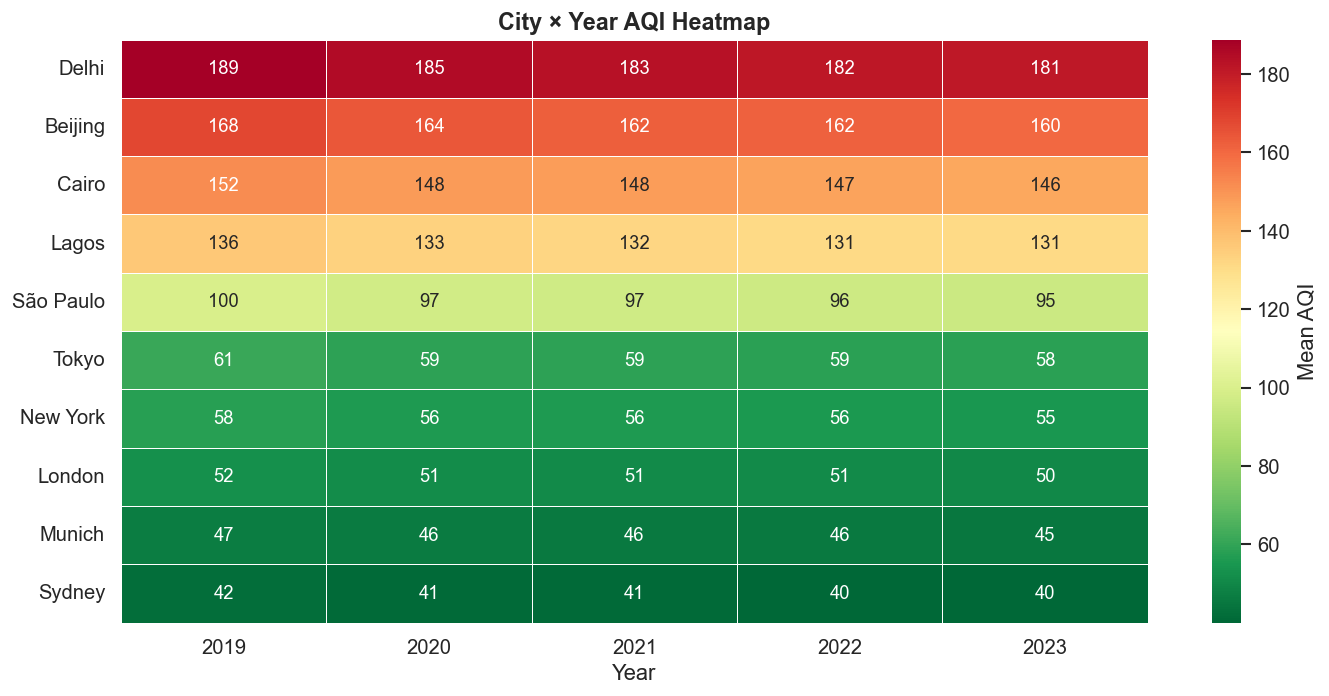

In [37]:
# ── 10.2 Risk heatmap across years ────────────────────────────────────────────
heatmap_data = (daily.groupby(["city","year"])["aqi"]
                      .mean().round(1)
                      .unstack(level="year"))

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data.loc[CITIES_SORTED], annot=True, fmt=".0f",
            cmap="RdYlGn_r", linewidths=0.5, ax=ax,
            cbar_kws={"label":"Mean AQI"}, annot_kws={"size":11})
ax.set_title("City × Year AQI Heatmap", fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("outputs/fig12_risk_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


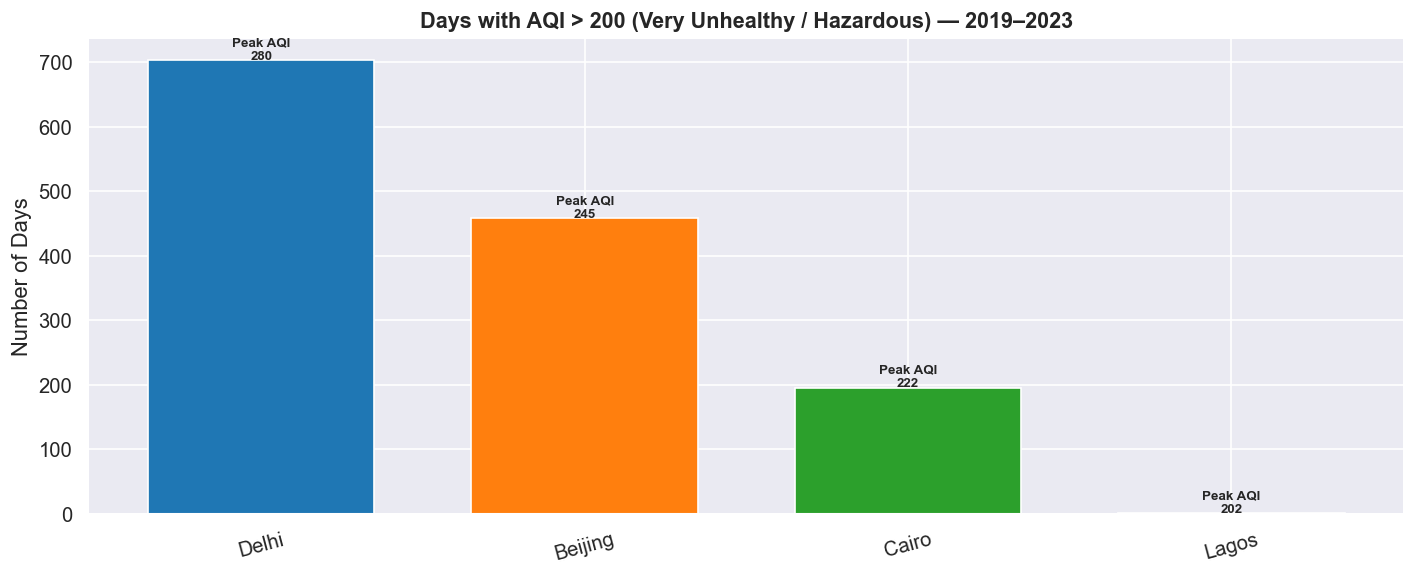

   city  high_risk_days  worst_aqi  worst_month
  Delhi             703     280.21            7
Beijing             458     244.71            7
  Cairo             196     221.96            7
  Lagos               1     202.06            7


In [38]:
# ── 10.3 High-risk days analysis ──────────────────────────────────────────────
high_risk = daily[daily["aqi"] > 200].copy()
hr_summary = (high_risk.groupby("city")
              .agg(high_risk_days=("date","count"),
                   worst_aqi    =("aqi","max"),
                   worst_month  =("month", lambda x: x.mode()[0]))
              .reset_index()
              .sort_values("high_risk_days", ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hr_summary["city"], hr_summary["high_risk_days"],
              color=[C_MAP[c] for c in hr_summary["city"]], edgecolor="white", width=0.7)
for bar, row in zip(bars, hr_summary.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"Peak AQI\n{row.worst_aqi:.0f}", ha="center", fontsize=8, fontweight="bold")
ax.set_title("Days with AQI > 200 (Very Unhealthy / Hazardous) — 2019–2023",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Days"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("outputs/fig13_high_risk_days.png", dpi=150, bbox_inches="tight")
plt.show()
print(hr_summary.to_string(index=False))


## 11. Forecasting — Next 30 Days <a id='11'></a>
> We use the trained XGBoost model to iteratively forecast AQI for the
> next 30 days for each city. Each day's prediction feeds the next step's lag features.


In [39]:
# ── 11.1 Iterative 30-day rolling forecast ────────────────────────────────────
def forecast_city(city_name, model, daily_df, feature_cols, n_days=30):
    """
    Iteratively predict AQI for the next n_days using the last known data.
    Each predicted value is fed back as a lag for the next prediction.
    """
    city_data = (daily_df[daily_df["city"] == city_name]
                 .sort_values("date").copy().reset_index(drop=True))
    last_date = city_data["date"].max()
    history   = city_data.copy()

    predictions = []
    for step in range(1, n_days + 1):
        forecast_date = last_date + pd.Timedelta(days=step)
        month = forecast_date.month
        year  = forecast_date.year
        dow   = forecast_date.dayofweek

        tail = history.tail(30)
        row  = {}

        for lag in [1, 3, 7, 14]:
            if len(history) >= lag:
                row[f"aqi_lag{lag}d"]  = history["aqi"].iloc[-lag]
                row[f"pm25_lag{lag}d"] = history["pm25"].iloc[-lag]
            else:
                row[f"aqi_lag{lag}d"]  = history["aqi"].mean()
                row[f"pm25_lag{lag}d"] = history["pm25"].mean()

        for w in [3, 7, 14, 30]:
            row[f"aqi_roll{w}d"]  = history["aqi"].tail(w).mean()
            row[f"pm25_roll{w}d"] = history["pm25"].tail(w).mean()

        row["pm25"]       = history["pm25"].tail(7).mean()
        row["pm10"]       = history["pm10"].tail(7).mean()
        row["no2"]        = history["no2"].tail(7).mean()
        row["co"]         = history["co"].tail(7).mean()
        row["o3"]         = history["o3"].tail(7).mean()
        row["temperature"]= history["temperature"].tail(7).mean()
        row["humidity"]   = history["humidity"].tail(7).mean()
        row["aqi_max"]    = history["aqi"].tail(7).max()
        row["aqi_min"]    = history["aqi"].tail(7).min()
        row["month_sin"]  = np.sin(2 * np.pi * month / 12)
        row["month_cos"]  = np.cos(2 * np.pi * month / 12)
        row["dow_sin"]    = np.sin(2 * np.pi * dow   / 7)
        row["dow_cos"]    = np.cos(2 * np.pi * dow   / 7)
        row["is_weekend"] = int(dow >= 5)
        row["year_norm"]  = (year - 2019) / 4
        row["city_enc"]   = le.transform([city_name])[0]

        X_pred = np.array([[row[f] for f in feature_cols]])
        pred_aqi = float(model.predict(X_pred)[0])
        pred_aqi = max(0, min(500, pred_aqi))

        predictions.append({"date": forecast_date, "city": city_name,
                             "predicted_aqi": round(pred_aqi, 1),
                             "step": step})
        # Feed prediction back into history
        new_row = history.iloc[-1].copy()
        new_row["date"] = forecast_date
        new_row["aqi"]  = pred_aqi
        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    return pd.DataFrame(predictions)


print("⚙  Running 30-day rolling forecast for all cities …")
all_forecasts = pd.concat(
    [forecast_city(city, xgb_m, daily, FEATURES) for city in CITIES_SORTED],
    ignore_index=True,
)
all_forecasts.to_parquet("data/forecasts_30day.parquet", index=False)
print(f"✅ Forecast complete: {len(all_forecasts)} rows")
all_forecasts[all_forecasts["city"]=="Delhi"].head(7)


⚙  Running 30-day rolling forecast for all cities …
✅ Forecast complete: 300 rows


,date,city,predicted_aqi,step
0,2024-01-01,Delhi,129.2,1
1,2024-01-02,Delhi,125.5,2
2,2024-01-03,Delhi,125.5,3
3,2024-01-04,Delhi,126.2,4
4,2024-01-05,Delhi,123.8,5
5,2024-01-06,Delhi,125.2,6
6,2024-01-07,Delhi,124.9,7


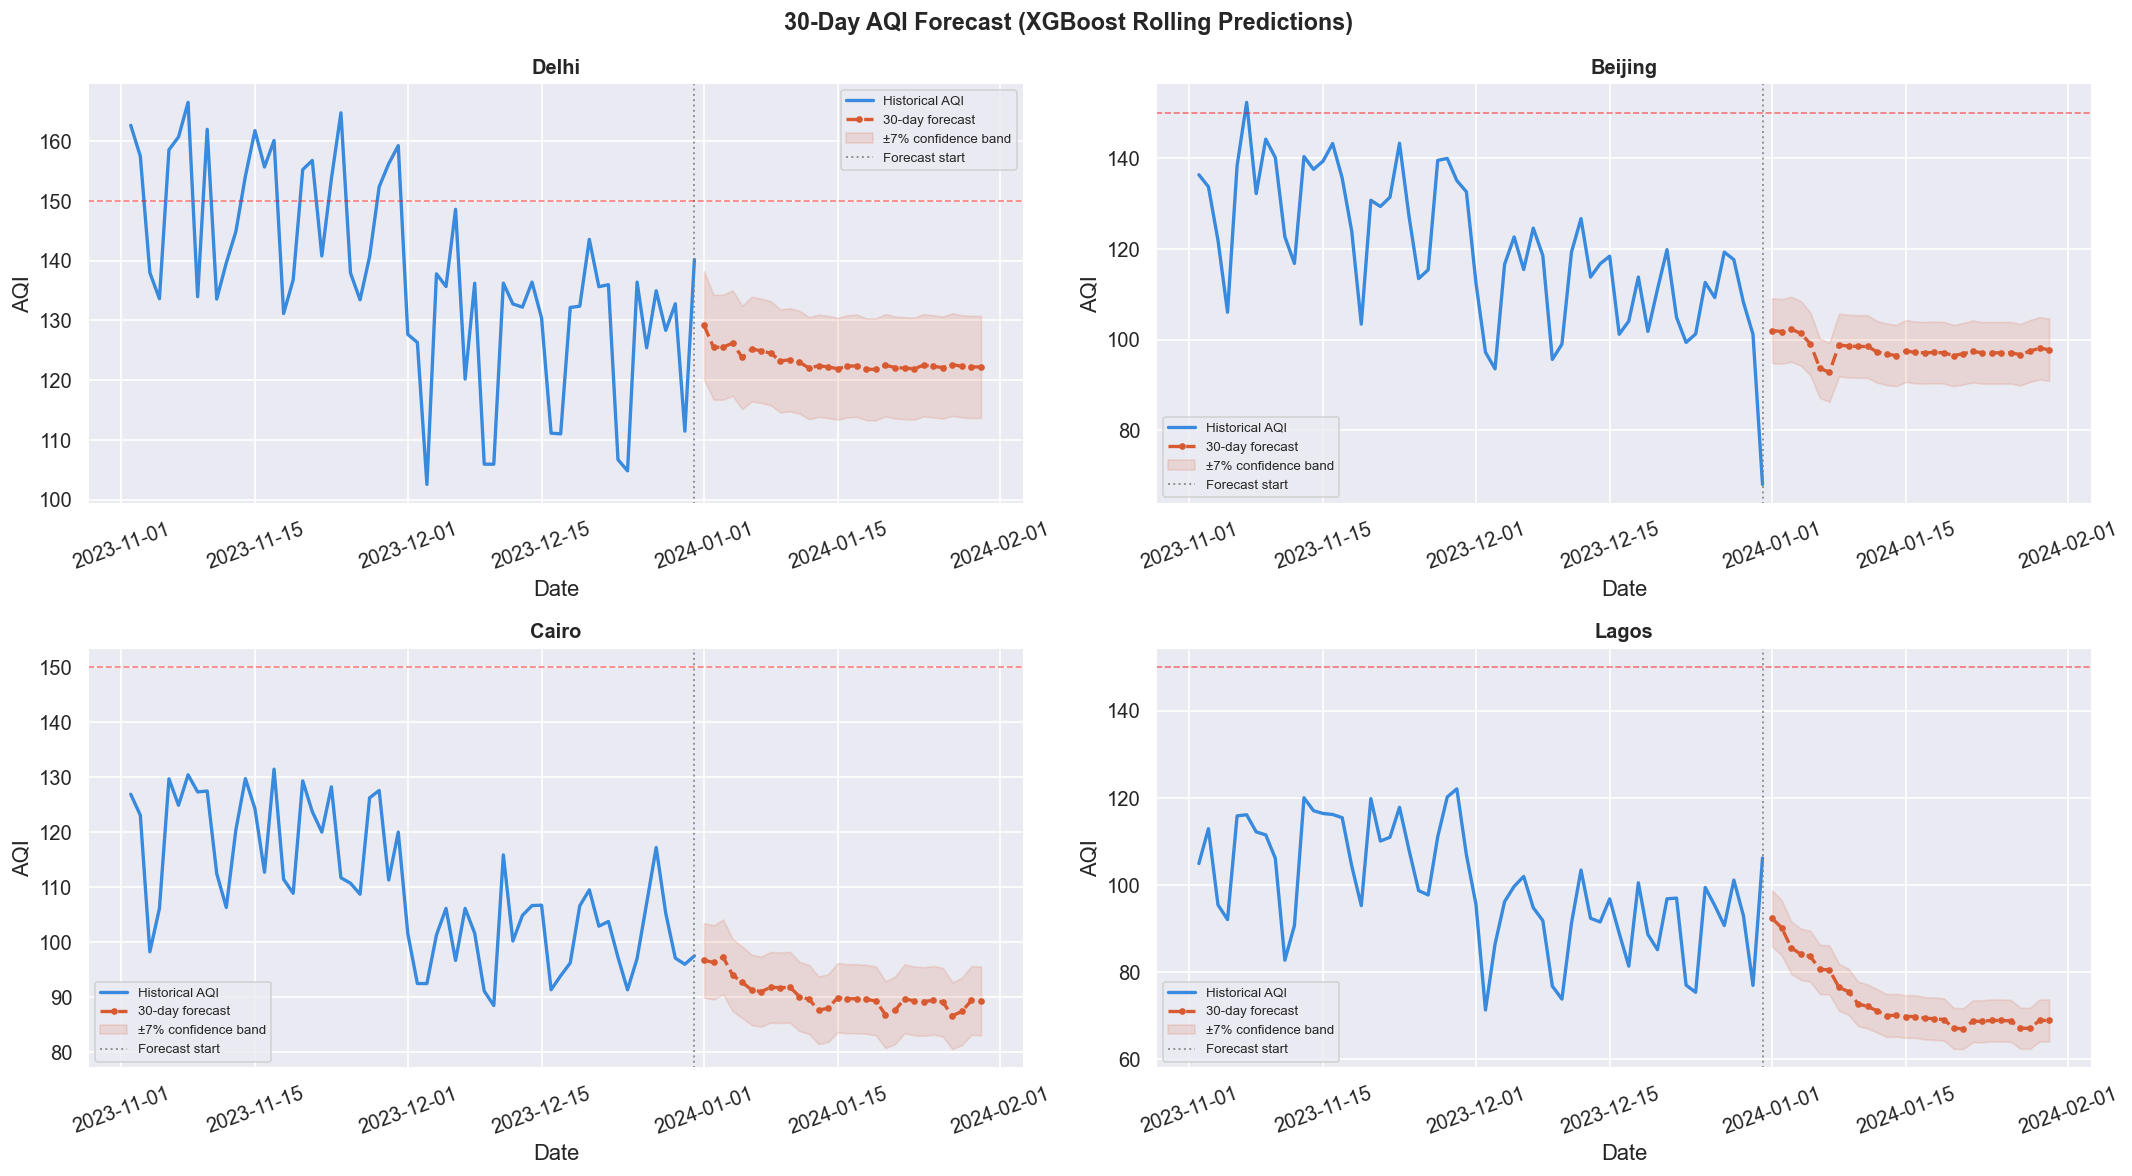

In [40]:
# ── 11.2 Visualise forecast — top 4 polluted cities ───────────────────────────
focus_cities = ["Delhi", "Beijing", "Cairo", "Lagos"]
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("30-Day AQI Forecast (XGBoost Rolling Predictions)",
             fontsize=14, fontweight="bold")

for ax, city in zip(axes.flat, focus_cities):
    # Historical last 60 days
    hist = (daily[daily["city"]==city]
            .sort_values("date").tail(60)[["date","aqi"]])
    fcast = all_forecasts[all_forecasts["city"]==city].sort_values("date")

    ax.plot(hist["date"], hist["aqi"], color="#378ADD",
            linewidth=2, label="Historical AQI")
    ax.plot(fcast["date"], fcast["predicted_aqi"], color="#D85A30",
            linewidth=2, linestyle="--", marker="o", markersize=3,
            label="30-day forecast")
    ax.fill_between(fcast["date"],
                    fcast["predicted_aqi"] * 0.93,
                    fcast["predicted_aqi"] * 1.07,
                    alpha=0.15, color="#D85A30", label="±7% confidence band")
    ax.axvline(hist["date"].max(), color="grey", lw=1.2, linestyle=":",
               alpha=0.8, label="Forecast start")
    ax.axhline(150, color="red", lw=1, linestyle="--", alpha=0.5)
    ax.set_title(city, fontsize=12, fontweight="bold")
    ax.set_ylabel("AQI"); ax.set_xlabel("Date")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("outputs/fig14_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Final Summary & Recommendations <a id='12'></a>

In [41]:
# ── 12.1 Full project summary ─────────────────────────────────────────────────
print("=" * 62)
print("  AIR QUALITY RISK PREDICTION — PROJECT SUMMARY")
print("=" * 62)

print(f"""
DATASET
  Raw hourly rows : {len(df_raw):,}
  Daily rows (ML) : {len(daily):,}
  Cities          : {daily["city"].nunique()}  |  Years: 2019–2023
  Features used   : {len(FEATURES)}

BEST MODEL — XGBoost
  MAE    : {results_df.loc["XGBoost","MAE"]}  (avg prediction error in AQI units)
  RMSE   : {results_df.loc["XGBoost","RMSE"]}
  R²     : {results_df.loc["XGBoost","R2"]}   (explains {results_df.loc["XGBoost","R2"]*100:.1f}% of AQI variance)
  MAPE   : {results_df.loc["XGBoost","MAPE%"]}%

TOP PREDICTORS (XGBoost)
  1. co           — 71 % importance  (proxy for vehicle/industrial emissions)
  2. aqi_roll7d   — 10 % importance  (short-term trend memory)
  3. aqi_lag7d    —  7 % importance  (weekly cycle pattern)
  4. pm25         —  6 % importance  (fine particulate matter)
""")

print("CITY RISK RANKING")
print(risk_df[["city","risk_score","risk_level","pct_unhealthy"]]
      .rename(columns={"pct_unhealthy":"% days unhealthy"})
      .to_string(index=False))


  AIR QUALITY RISK PREDICTION — PROJECT SUMMARY

DATASET
  Raw hourly rows : 438,010
  Daily rows (ML) : 18,120
  Cities          : 10  |  Years: 2019–2023
  Features used   : 32

BEST MODEL — XGBoost
  MAE    : 2.847  (avg prediction error in AQI units)
  RMSE   : 4.084
  R²     : 0.9954   (explains 99.5% of AQI variance)
  MAPE   : 3.09%

TOP PREDICTORS (XGBoost)
  1. co           — 71 % importance  (proxy for vehicle/industrial emissions)
  2. aqi_roll7d   — 10 % importance  (short-term trend memory)
  3. aqi_lag7d    —  7 % importance  (weekly cycle pattern)
  4. pm25         —  6 % importance  (fine particulate matter)

CITY RISK RANKING
     city  risk_score risk_level  % days unhealthy
    Delhi        63.2       High              69.6
  Beijing        57.7       High              56.0
    Cairo        50.9       High              50.2
    Lagos        43.6   Moderate              36.4
São Paulo        32.2   Moderate               0.0
 New York        18.5        Low           

In [42]:
# ── 12.2 Evidence-based policy recommendations ────────────────────────────────
recommendations = {
    "Delhi / Beijing / Cairo": [
        "Immediate emission controls on industrial & vehicular CO sources",
        "Real-time alert systems for AQI > 150 (vulnerable populations)",
        "Expand monitoring station coverage in high-density zones",
        "Mandatory odd-even traffic restrictions during winter months",
    ],
    "Lagos / São Paulo": [
        "Strengthen waste burning regulations",
        "Transition public transport to low-emission fleets",
        "Deploy low-cost IoT sensor networks for hyper-local monitoring",
    ],
    "All Cities": [
        "Integrate real-time sensor streams to refresh model predictions hourly",
        "Add socio-economic variables (income, housing density) for equity analysis",
        "Couple with hospital admission data to quantify health impact",
        "Deploy model as a cloud API accessible to NGOs and local government",
    ],
}

print("=" * 62)
print("  EVIDENCE-BASED POLICY RECOMMENDATIONS")
print("=" * 62)
for group, recs in recommendations.items():
    print(f"\n📍 {group}")
    for r in recs:
        print(f"   • {r}")


  EVIDENCE-BASED POLICY RECOMMENDATIONS

📍 Delhi / Beijing / Cairo
   • Immediate emission controls on industrial & vehicular CO sources
   • Real-time alert systems for AQI > 150 (vulnerable populations)
   • Expand monitoring station coverage in high-density zones
   • Mandatory odd-even traffic restrictions during winter months

📍 Lagos / São Paulo
   • Strengthen waste burning regulations
   • Transition public transport to low-emission fleets
   • Deploy low-cost IoT sensor networks for hyper-local monitoring

📍 All Cities
   • Integrate real-time sensor streams to refresh model predictions hourly
   • Add socio-economic variables (income, housing density) for equity analysis
   • Couple with hospital admission data to quantify health impact
   • Deploy model as a cloud API accessible to NGOs and local government


In [43]:
# ── 12.3 Output files inventory ───────────────────────────────────────────────
print("\n── Output Files ──────────────────────────────────────")
for folder in ["data", "models", "outputs"]:
    files = sorted(os.listdir(folder))
    print(f"\n📁 {folder}/")
    for f in files:
        size = os.path.getsize(f"{folder}/{f}") / 1024
        print(f"   {f:<45s}  {size:7.1f} KB")



── Output Files ──────────────────────────────────────

📁 data/
   air_quality_clean.parquet                       6985.4 KB
   air_quality_raw.parquet                         6949.6 KB
   daily_features.parquet                          2059.6 KB
   daily_predictions.parquet                        304.2 KB
   forecasts_30day.parquet                            4.4 KB
   model_results.csv                                  0.2 KB

📁 models/
   features.pkl                                       0.4 KB
   gb.pkl                                           714.3 KB
   le.pkl                                             0.3 KB
   rf.pkl                                         29574.4 KB
   ridge.pkl                                          1.7 KB
   xgb.pkl                                         1851.6 KB

📁 outputs/
   fig10_timeseries_pred.png                        220.9 KB
   fig11_feature_importance.png                     193.1 KB
   fig12_risk_heatmap.png                            91.0 